# Eigenportfolio Construction via Random Matrix Theory
## Separating Signal from Noise in Large Covariance Matrices

**Author:** David Colindres | B.S./M.S. Industrial & Systems Engineering, University of Oklahoma  
**Date:** March 2026  
**Purpose:** MFE / MSCF / MSFE Admissions Portfolio — Project 2 of 3

---

## Executive Summary

The sample covariance matrix — the foundation of portfolio optimization, risk modeling, and factor analysis — is mostly noise. When the number of assets $n$ is comparable to the number of observations $T$, **random matrix theory (RMT)** shows that the bulk of the eigenvalue spectrum is indistinguishable from a purely random matrix. Only eigenvalues exceeding the **Marchenko–Pastur upper edge** carry genuine correlation structure.

This project implements a complete pipeline: compute the empirical eigenvalue spectrum of a 200-asset covariance matrix, fit the Marchenko–Pastur null, classify signal vs. noise, denoise the matrix, construct eigenportfolios, and test whether cleaned covariance produces superior out-of-sample portfolios.

### Key References
- Laloux, Cizeau, Bouchaud, Potters (1999). *Noise dressing of financial correlation matrices.*
- Bun, Bouchaud, Potters (2017). *Cleaning large correlation matrices.*
- Marchenko & Pastur (1967). *Distribution of eigenvalues for some sets of random matrices.*
- Ledoit & Wolf (2004). *A well-conditioned estimator for large-dimensional covariance matrices.*

---

## Table of Contents

1. [Configuration & Setup](#1)
2. [Data Ingestion & Cleaning](#2)
3. [Exploratory Data Analysis](#3)
4. [Eigenvalue Decomposition & the Noise Problem](#4)
5. [Marchenko–Pastur Distribution Fit](#5)
6. [Signal-Noise Separation](#6)
7. [Covariance Matrix Cleaning](#7)
8. [Eigenportfolio Construction & Interpretation](#8)
9. [Portfolio Construction: Min-Var with Cleaned Covariance](#9)
10. [Benchmark Strategies](#10)
11. [Rolling Backtest Engine](#11)
12. [Performance Evaluation](#12)
13. [Sensitivity Analysis](#13)
14. [Regime-Conditioned Evaluation](#14)
15. [Failure Mode Analysis](#15)
16. [Conclusions & Limitations](#16)


---
<a id="1"></a>
## 1. Configuration & Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
from datetime import datetime
from scipy import stats, optimize
from sklearn.covariance import LedoitWolf
import cvxpy as cp
import yfinance as yf

np.random.seed(42)
warnings.filterwarnings('ignore')

# ROADMAP 2.1: repo root on sys.path (this machine skips .pth processing),
# shared dark theme from common/plotting instead of a local rcParams block.
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('../../..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)
_SRC = str((_Path('../../..') / 'projects/02_eigenportfolio_rmt/src').resolve())
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)
import eigenrmt
from eigenrmt import (compute_eigen, marchenko_pastur_pdf, mp_edges,
                      fit_mp_sigma, fit_mp_sigma_naive, classify_eigenvalues,
                      clean_covariance_hard_threshold,
                      clean_covariance_targeted_shrinkage,
                      clean_covariance_constant_residual,
                      build_eigenportfolios, min_variance_portfolio,
                      compute_tc, run_rmt_backtest)
print(f'eigenrmt loaded from {eigenrmt.__file__}')  # freshness proof (ROADMAP 2.2)
from common.plotting import apply_theme
apply_theme()

COLORS = {
    'rmt_clean': '#00d4aa',   'raw_cov': '#ff6b6b',     'ledoit_wolf': '#ffd93d',
    'equal_wt': '#4ecdc4',    'sp500': '#6b7280',        'eigenport': '#c084fc',
    'signal': '#22c55e',      'noise': '#ef4444',         'mp_theory': '#3b82f6',
    'accent': '#f59e0b',
}

print("Environment ready.")
print(f"CVXPY: {cp.__version__} | NumPy: {np.__version__} | pandas: {pd.__version__}")


eigenrmt loaded from /Users/davidcolindres/Documents/Quant/ISE/Quant/OUQuant/Projects/V2/quant-research/projects/02_eigenportfolio_rmt/src/eigenrmt/__init__.py
Environment ready.
CVXPY: 1.9.2 | NumPy: 2.5.1 | pandas: 3.0.3


In [2]:
# ═══════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════

# Build a 200-asset universe from S&P 500 large/mid caps
# ROADMAP 2.3: parameters live in ../config.yaml — generated from this
# cell's former CONFIG dict, schema-validated by common/config.py (loud
# failure on missing/unknown keys or bad types; no silent defaults).
from common.config import load_config
CONFIG = load_config('../config.yaml', project='p2')


n_target = len(CONFIG['tickers'])
print(f"Target universe: {n_target} assets")
print(f"Period: {CONFIG['start_date']} to {CONFIG['end_date']}")
print(f"q = n/T ≈ {n_target}/{CONFIG['lookback_days']} = {n_target/CONFIG['lookback_days']:.2f}")
print(f"  → This is the regime where RMT matters (q close to 1).")


Target universe: 180 assets
Period: 2005-01-01 to 2024-12-31
q = n/T ≈ 180/252 = 0.71
  → This is the regime where RMT matters (q close to 1).


**Population note (G-3 / ROADMAP 1.6).** This universe is ~200 *2024-era large caps* traded back to 2005 — i.e., **survivors**. Every result below is conditional on the population *"firms that became and remained large-cap through 2024"*: selection foreknowledge inflates early-period performance (measured in §16.1), the casualties of 2008 are censored out of the spectrum and the min-var drawdowns, and the realized universe (151 names, q = 0.599) is smaller than the spec's 200/0.79 premise. See `docs/LIMITATIONS.md`. The correct fix — point-in-time membership with delisting returns (CRSP) — is gated on a WRDS-access check.

**OOS Discipline Statement (ROADMAP 3.3).** IS = 2005-01-01…2017-12-31; OOS = 2018-01-01…2024-12-31; performance tables report Full/IS/OOS separately. No parameter was selected on OOS data: cleaning thresholds are recomputed each rebalance from trailing data only; the window×universe grid's question was pre-stated and its Sharpe columns are OOS-labeled comparisons with no selection performed; baseline T=252/full-universe fixed before the grid ran. Universe-level survivorship is the one disclosed leak (docs/LIMITATIONS.md §1). Trail: results/OOS_DISCIPLINE.md.

---
<a id="2"></a>
## 2. Data Ingestion & Cleaning

We need a **large** universe — 200 assets — because the ratio $q = n/T$ must be large enough that the Marchenko–Pastur distribution is meaningful. With $n = 200$ and $T = 252$, $q \approx 0.79$, putting us squarely in the regime where RMT reveals the noise problem.


In [3]:
# ─── 2.1 Download prices ───
print("Downloading price data for 200 assets (this may take a moment)...")
t0 = time.time()

# ROADMAP 2.1: download + cache via common/data.py (same parquet snapshot)
from pathlib import Path
from common.data import download_prices, clean_prices
DATA_DIR = Path('../../../data')
DATA_DIR.mkdir(exist_ok=True)

raw_prices = download_prices(CONFIG['tickers'], CONFIG['start_date'], CONFIG['end_date'],
                             cache_name='p2_prices_2005_2024.parquet')
raw_prices = raw_prices.dropna(axis=1, how='all')
downloaded = list(raw_prices.columns)
failed = [t for t in CONFIG['tickers'] if t not in downloaded]

print(f"Downloaded: {len(downloaded)} / {n_target} tickers in {time.time()-t0:.1f}s")
if failed:
    print(f"Failed: {len(failed)} tickers")
print(f"Date range: {raw_prices.index[0].date()} to {raw_prices.index[-1].date()}")


Downloaded: 172 / 180 tickers in 0.2s
Failed: 8 tickers
Date range: 2005-01-03 to 2024-12-30


In [4]:
# ─── 2.2 Clean data ───
# ROADMAP 2.1: cleaning via common/data.py — identical rules, plus explicit ret_simple (G-2)
prices, returns, returns_simple, cleaning_log = clean_prices(raw_prices)
for msg in cleaning_log:
    print(msg)

n_assets = returns.shape[1]
asset_names = list(returns.columns)
print(f"\nEffective q = {n_assets}/{CONFIG['lookback_days']} = {n_assets/CONFIG['lookback_days']:.3f}")


Removed 21 assets with >5% missing data
Winsorized 2658 observations at ±5.0σ
Final: 151 assets, 4810 days

Effective q = 151/252 = 0.599


---
<a id="3"></a>
## 3. Exploratory Data Analysis

Before applying RMT, we examine the basic statistical properties of our 200-asset return matrix. The key observations that motivate this project: fat tails, high average correlation, and the sheer dimensionality of the estimation problem.


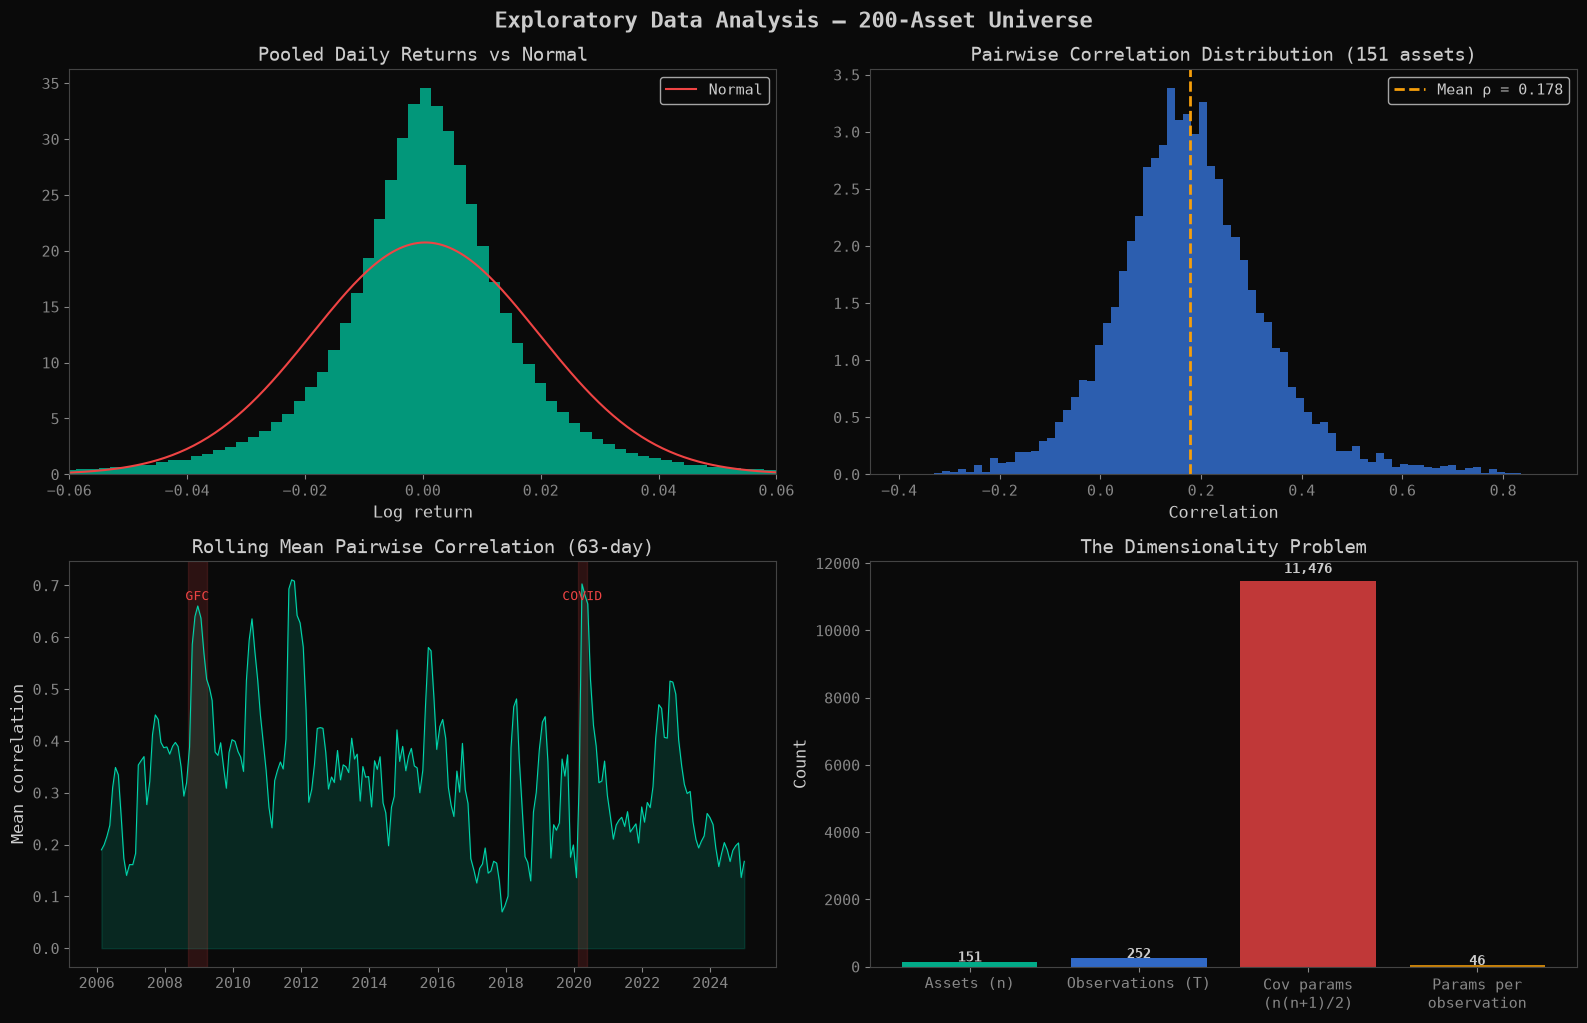


Key statistics:
  Assets: 151
  Covariance parameters: 11,476
  Observations per window: 252
  Parameters per observation: 45.5
  q = n/T = 0.599
→ We are estimating ~46 parameters per data point.
  This is the regime where most of the sample covariance is NOISE.


In [5]:
# ─── 3.1 Return distributions and correlation overview ───
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Pooled return distribution
ax = axes[0, 0]
pooled = returns.values.flatten()
pooled = pooled[~np.isnan(pooled)]
ax.hist(pooled, bins=200, density=True, alpha=0.7, color=COLORS['rmt_clean'], edgecolor='none')
x = np.linspace(-0.06, 0.06, 200)
ax.plot(x, stats.norm.pdf(x, pooled.mean(), pooled.std()), color=COLORS['noise'], lw=1.5, label='Normal')
ax.set_title('Pooled Daily Returns vs Normal')
ax.set_xlabel('Log return')
ax.legend()
ax.set_xlim(-0.06, 0.06)

# (b) Cross-sectional correlation distribution
ax = axes[0, 1]
corr_matrix = returns.iloc[-252:].corr()
upper_tri = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
ax.hist(upper_tri, bins=80, density=True, alpha=0.7, color=COLORS['mp_theory'], edgecolor='none')
ax.axvline(upper_tri.mean(), color=COLORS['accent'], lw=2, ls='--', label=f'Mean ρ = {upper_tri.mean():.3f}')
ax.set_title(f'Pairwise Correlation Distribution ({n_assets} assets)')
ax.set_xlabel('Correlation')
ax.legend()

# (c) Rolling mean correlation
ax = axes[1, 0]
from eigenrmt import rolling_mean_corr  # moved to src (2.2)
mean_corr = rolling_mean_corr(returns)
ax.plot(mean_corr.index, mean_corr.values, color=COLORS['rmt_clean'], lw=0.8)
ax.fill_between(mean_corr.index, 0, mean_corr.values, alpha=0.15, color=COLORS['rmt_clean'])
ax.set_title('Rolling Mean Pairwise Correlation (63-day)')
ax.set_ylabel('Mean correlation')

for label, start, end in [('GFC', '2008-09-01', '2009-03-31'), ('COVID', '2020-02-15', '2020-05-15')]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=COLORS['noise'])
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1]*0.9, label, ha='center', fontsize=9, color=COLORS['noise'])

# (d) Dimension challenge
ax = axes[1, 1]
n = n_assets
params_cov = n * (n + 1) // 2
params_per_obs = params_cov / CONFIG['lookback_days']
ax.bar(['Assets (n)', 'Observations (T)', 'Cov params\n(n(n+1)/2)', 'Params per\nobservation'],
       [n, CONFIG['lookback_days'], params_cov, params_per_obs],
       color=[COLORS['rmt_clean'], COLORS['mp_theory'], COLORS['noise'], COLORS['accent']], alpha=0.8)
ax.set_title('The Dimensionality Problem')
ax.set_ylabel('Count')
for i, v in enumerate([n, CONFIG['lookback_days'], params_cov, params_per_obs]):
    ax.text(i, v + v*0.02, f'{v:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.suptitle('Exploratory Data Analysis — 200-Asset Universe', y=1.02, fontsize=16, fontweight='bold')
plt.show()

print(f"\nKey statistics:")
print(f"  Assets: {n_assets}")
print(f"  Covariance parameters: {n_assets*(n_assets+1)//2:,}")
print(f"  Observations per window: {CONFIG['lookback_days']}")
print(f"  Parameters per observation: {n_assets*(n_assets+1)//2 / CONFIG['lookback_days']:.1f}")
print(f"  q = n/T = {n_assets/CONFIG['lookback_days']:.3f}")
print(f"→ We are estimating ~{n_assets*(n_assets+1)//2 / CONFIG['lookback_days']:.0f} parameters per data point.")
print(f"  This is the regime where most of the sample covariance is NOISE.")


---
<a id="4"></a>
## 4. Eigenvalue Decomposition & the Noise Problem

We compute the eigendecomposition of the sample correlation matrix:

$$C = \frac{1}{T} X^T X = V \Lambda V^T$$

where $X$ is the standardized (zero-mean, unit-variance) return matrix. The eigenvalues $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_n$ reveal how much variance each principal component captures. The question is: **how many of these eigenvalues carry real information, and how many are just noise?**


In [6]:
# ─── 4.1 Eigendecomposition function ───

# Compute for last 252-day window
demo_window = returns.iloc[-CONFIG['lookback_days']:]
eigvals, eigvecs, corr_mat, eigen_meta = compute_eigen(demo_window)

print(f"Eigendecomposition of {eigen_meta['n']}×{eigen_meta['n']} correlation matrix")
print(f"  q = n/T = {eigen_meta['q']:.3f}")
print(f"  Condition number: {eigen_meta['condition_number']:.0f}")
print(f"  Trace: {eigen_meta['trace']:.2f} (should ≈ {eigen_meta['n']})")
print(f"  Top 1 eigenvalue captures: {eigen_meta['top1_var_pct']:.1%} of total variance")
print(f"  Top 5 eigenvalues capture: {eigen_meta['top5_var_pct']:.1%}")
print(f"  Top 10 eigenvalues capture: {eigen_meta['top10_var_pct']:.1%}")
print(f"  Remaining {eigen_meta['n']-10} eigenvalues: {1-eigen_meta['top10_var_pct']:.1%}")


Eigendecomposition of 151×151 correlation matrix
  q = n/T = 0.599
  Condition number: 1435
  Trace: 151.00 (should ≈ 151)
  Top 1 eigenvalue captures: 19.9% of total variance
  Top 5 eigenvalues capture: 41.9%
  Top 10 eigenvalues capture: 51.3%
  Remaining 141 eigenvalues: 48.7%


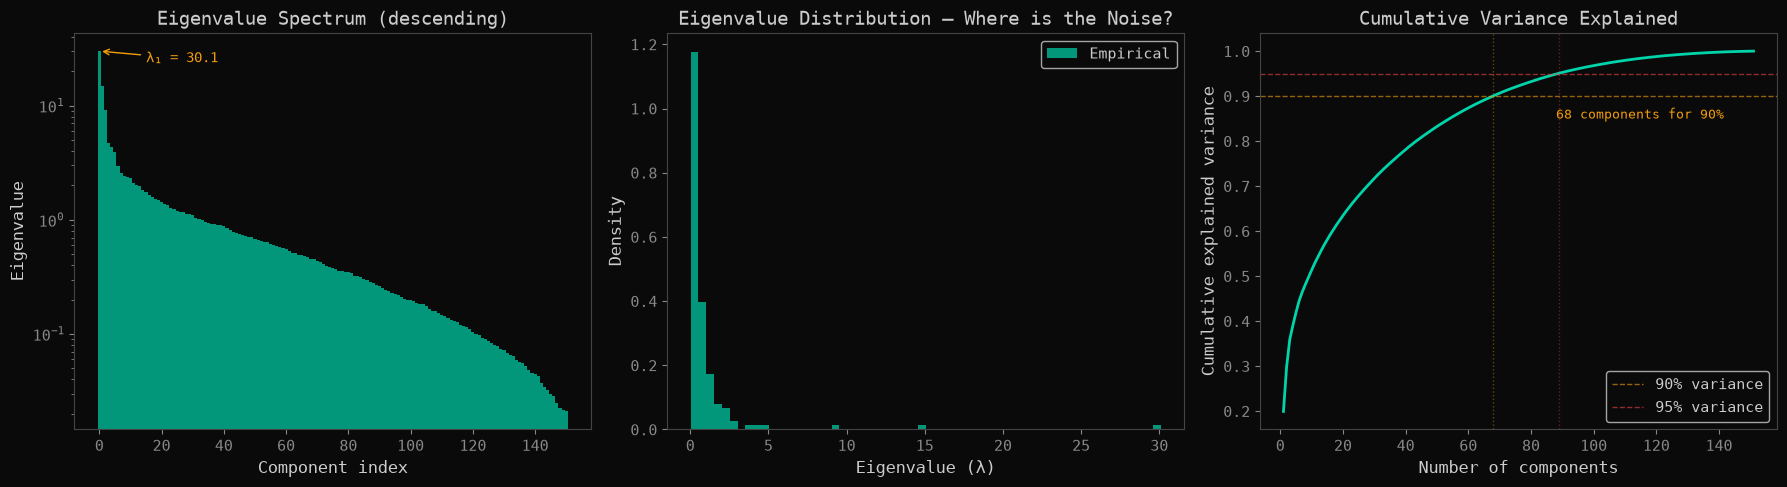

→ The first eigenvalue (market factor) is massive: λ₁ = 30.1
  But most eigenvalues cluster near 1.0 — are they signal or noise?
  RMT gives us a principled way to answer this question.


In [7]:
# ─── 4.2 Visualize the eigenvalue spectrum (raw) ───

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Eigenvalue bar plot
ax = axes[0]
ax.bar(range(len(eigvals)), eigvals, color=COLORS['rmt_clean'], alpha=0.7, width=1.0)
ax.set_xlabel('Component index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Spectrum (descending)')
ax.set_yscale('log')
ax.annotate(f'λ₁ = {eigvals[0]:.1f}', xy=(0, eigvals[0]),
            xytext=(15, eigvals[0]*0.8), fontsize=10, color=COLORS['accent'],
            arrowprops=dict(arrowstyle='->', color=COLORS['accent']))

# (b) Eigenvalue histogram (the key plot for RMT)
ax = axes[1]
ax.hist(eigvals, bins=60, density=True, alpha=0.7, color=COLORS['rmt_clean'],
        edgecolor='none', label='Empirical')
ax.set_xlabel('Eigenvalue (λ)')
ax.set_ylabel('Density')
ax.set_title('Eigenvalue Distribution — Where is the Noise?')
ax.legend()

# (c) Cumulative explained variance
ax = axes[2]
cum_var = np.cumsum(eigvals) / eigvals.sum()
ax.plot(range(1, len(eigvals)+1), cum_var, color=COLORS['rmt_clean'], lw=2)
ax.axhline(0.9, color=COLORS['accent'], ls='--', lw=1, alpha=0.6, label='90% variance')
ax.axhline(0.95, color=COLORS['noise'], ls='--', lw=1, alpha=0.6, label='95% variance')
n_90 = np.searchsorted(cum_var, 0.9) + 1
n_95 = np.searchsorted(cum_var, 0.95) + 1
ax.axvline(n_90, color=COLORS['accent'], ls=':', lw=1, alpha=0.4)
ax.axvline(n_95, color=COLORS['noise'], ls=':', lw=1, alpha=0.4)
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('Cumulative Variance Explained')
ax.legend()
ax.annotate(f'{n_90} components for 90%', xy=(n_90, 0.9),
            xytext=(n_90+20, 0.85), fontsize=9, color=COLORS['accent'])

plt.tight_layout()
plt.show()

print(f"→ The first eigenvalue (market factor) is massive: λ₁ = {eigvals[0]:.1f}")
print(f"  But most eigenvalues cluster near 1.0 — are they signal or noise?")
print(f"  RMT gives us a principled way to answer this question.")


---
<a id="5"></a>
## 5. Marchenko–Pastur Distribution Fit

The **Marchenko–Pastur (MP) law** gives the theoretical eigenvalue density for a random correlation matrix when $n$ and $T$ are both large with $q = n/T$ fixed:

$$\rho_{MP}(\lambda) = \frac{T}{2\pi \sigma^2 q} \cdot \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{\lambda}$$

where $\lambda_{\pm} = \sigma^2(1 \pm \sqrt{q})^2$ are the theoretical edges.

**Key insight:** Any eigenvalue of the sample correlation matrix that falls *within* the MP support $[\lambda_-, \lambda_+]$ is consistent with noise — it would appear even if the returns were completely uncorrelated. Only eigenvalues *exceeding* $\lambda_+$ are statistically distinguishable from noise.


In [8]:
# ─── 5.1 Marchenko-Pastur machinery — now in src/eigenrmt/rmt.py (2.2) ───
# ─── 5.1 Marchenko-Pastur distribution ───

# Compute MP parameters
q = n_assets / CONFIG['lookback_days']
sigma2_fit = fit_mp_sigma(eigvals, q)
lam_minus, lam_plus = mp_edges(q, sigma2_fit)
sigma2_naive = fit_mp_sigma_naive(eigvals, q)
_, lam_plus_naive = mp_edges(q, sigma2_naive)
print(f"Naive vs iterative edge: λ₊ {lam_plus_naive:.4f} (one-pass) → {lam_plus:.4f} (iterative)")

print(f"Marchenko-Pastur Parameters:")
print(f"  q = n/T = {q:.4f}")
print(f"  σ² (fitted) = {sigma2_fit:.4f}")
print(f"  λ₋ (lower edge) = {lam_minus:.4f}")
print(f"  λ₊ (upper edge) = {lam_plus:.4f}")
print(f"  Eigenvalues above λ₊: {(eigvals > lam_plus).sum()} out of {len(eigvals)}")
print(f"  → These are the SIGNAL eigenvalues. Everything else is NOISE.")


Naive vs iterative edge: λ₊ 1.8188 (one-pass) → 1.2325 (iterative)
Marchenko-Pastur Parameters:
  q = n/T = 0.5992
  σ² (fitted) = 0.3916
  λ₋ (lower edge) = 0.0200
  λ₊ (upper edge) = 1.2325
  Eigenvalues above λ₊: 24 out of 151
  → These are the SIGNAL eigenvalues. Everything else is NOISE.


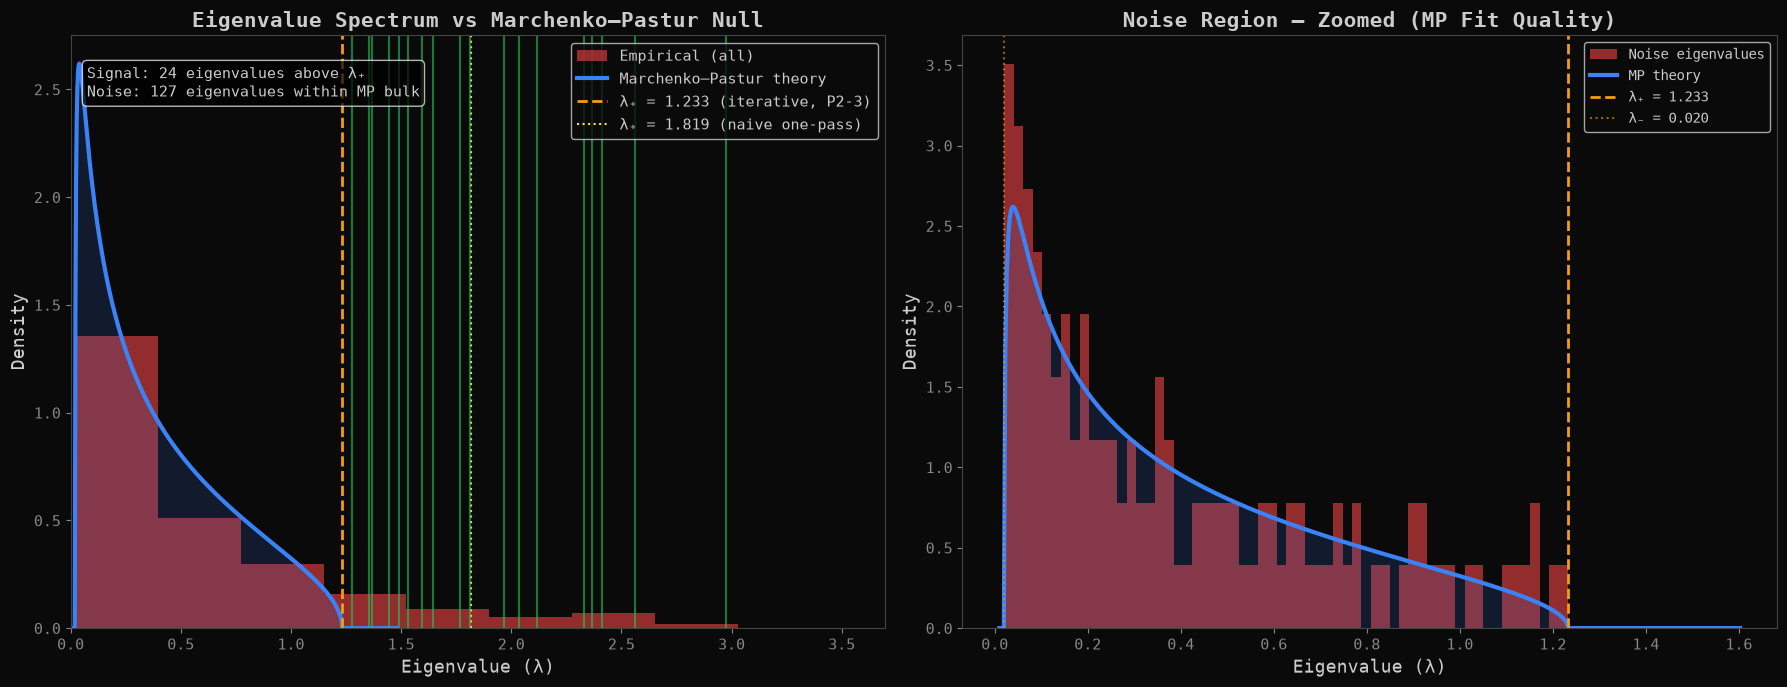


→ The MP distribution fits the noise bulk remarkably well.
   24 eigenvalues escape above λ₊ = 1.233 — these carry REAL structure.
   The remaining 127 are indistinguishable from random noise.


In [9]:
# ─── 5.2 THE SIGNATURE PLOT: Eigenvalue spectrum vs MP theory ───
# This is the most important visualization in the entire project.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# (a) Full spectrum overlay
ax = axes[0]

# Empirical histogram
ax.hist(eigvals, bins=80, density=True, alpha=0.6, color=COLORS['noise'],
        edgecolor='none', label='Empirical (all)')

# Separate noise vs signal
noise_eigvals = eigvals[eigvals <= lam_plus]
signal_eigvals = eigvals[eigvals > lam_plus]

# MP theoretical density
x_range = np.linspace(max(0.01, lam_minus * 0.8), lam_plus * 1.2, 500)
mp_density = marchenko_pastur_pdf(x_range, q, sigma2_fit)
ax.plot(x_range, mp_density, color=COLORS['mp_theory'], lw=3, label='Marchenko–Pastur theory')
ax.fill_between(x_range, 0, mp_density, alpha=0.15, color=COLORS['mp_theory'])

# Mark the upper edge
ax.axvline(lam_plus, color=COLORS['accent'], lw=2, ls='--',
           label=f'λ₊ = {lam_plus:.3f} (iterative, P2-3)')
ax.axvline(lam_plus_naive, color=COLORS['ledoit_wolf'], lw=1.5, ls=':',
           label=f'λ₊ = {lam_plus_naive:.3f} (naive one-pass)')

# Mark signal eigenvalues
for i, lam in enumerate(signal_eigvals):
    if lam < 20:  # don't go off-chart
        ax.axvline(lam, color=COLORS['signal'], lw=1.5, alpha=0.6)

ax.set_xlabel('Eigenvalue (λ)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Eigenvalue Spectrum vs Marchenko–Pastur Null', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.set_xlim(0, min(lam_plus * 3, eigvals[3] * 1.5))

# Annotate
n_signal = len(signal_eigvals)
ax.text(0.02, 0.95, f'Signal: {n_signal} eigenvalues above λ₊\n'
        f'Noise: {len(noise_eigvals)} eigenvalues within MP bulk',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

# (b) Zoomed into the noise region
ax = axes[1]
ax.hist(noise_eigvals, bins=60, density=True, alpha=0.6, color=COLORS['noise'],
        edgecolor='none', label='Noise eigenvalues')
x_zoom = np.linspace(max(0.01, lam_minus * 0.5), lam_plus * 1.3, 500)
mp_zoom = marchenko_pastur_pdf(x_zoom, q, sigma2_fit)
ax.plot(x_zoom, mp_zoom, color=COLORS['mp_theory'], lw=3, label='MP theory')
ax.fill_between(x_zoom, 0, mp_zoom, alpha=0.15, color=COLORS['mp_theory'])
ax.axvline(lam_plus, color=COLORS['accent'], lw=2, ls='--', label=f'λ₊ = {lam_plus:.3f}')
ax.axvline(lam_minus, color=COLORS['accent'], lw=1.5, ls=':', alpha=0.6, label=f'λ₋ = {lam_minus:.3f}')
ax.set_xlabel('Eigenvalue (λ)', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Noise Region — Zoomed (MP Fit Quality)', fontsize=15, fontweight='bold')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n→ The MP distribution fits the noise bulk remarkably well.")
print(f"   {n_signal} eigenvalues escape above λ₊ = {lam_plus:.3f} — these carry REAL structure.")
print(f"   The remaining {len(noise_eigvals)} are indistinguishable from random noise.")


---
<a id="6"></a>
## 6. Signal-Noise Separation

We classify each eigenvalue as **signal** or **noise** based on the MP upper edge $\lambda_+$. The number of signal eigenvalues tells us the **effective dimensionality** of the correlation structure — how many independent risk factors actually drive our 200-asset universe.


In [10]:
# ─── 6.1 Classification and effective rank ───

is_signal, lam_plus, n_signal = classify_eigenvalues(eigvals, q)

print(f"Signal-Noise Classification:")
print(f"  Total eigenvalues: {len(eigvals)}")
print(f"  Signal (λ > λ₊):  {n_signal}")
print(f"  Noise (λ ≤ λ₊):   {len(eigvals) - n_signal}")
print(f"  λ₊ threshold:      {lam_plus:.4f}")
print(f"\nSignal eigenvalues:")
for i, lam in enumerate(eigvals[is_signal]):
    pct = lam / eigvals.sum() * 100
    print(f"  λ_{i+1} = {lam:.3f}  ({pct:.1f}% of variance)")
print(f"\n  Total signal variance: {eigvals[is_signal].sum() / eigvals.sum():.1%}")
print(f"  Total noise variance:  {eigvals[~is_signal].sum() / eigvals.sum():.1%}")


Signal-Noise Classification:
  Total eigenvalues: 151
  Signal (λ > λ₊):  24
  Noise (λ ≤ λ₊):   127
  λ₊ threshold:      1.2325

Signal eigenvalues:
  λ_1 = 30.087  (19.9% of variance)
  λ_2 = 14.834  (9.8% of variance)
  λ_3 = 9.243  (6.1% of variance)
  λ_4 = 4.749  (3.1% of variance)
  λ_5 = 4.379  (2.9% of variance)
  λ_6 = 3.913  (2.6% of variance)
  λ_7 = 2.973  (2.0% of variance)
  λ_8 = 2.562  (1.7% of variance)
  λ_9 = 2.412  (1.6% of variance)
  λ_10 = 2.368  (1.6% of variance)
  λ_11 = 2.330  (1.5% of variance)
  λ_12 = 2.119  (1.4% of variance)
  λ_13 = 2.037  (1.3% of variance)
  λ_14 = 1.967  (1.3% of variance)
  λ_15 = 1.814  (1.2% of variance)
  λ_16 = 1.768  (1.2% of variance)
  λ_17 = 1.647  (1.1% of variance)
  λ_18 = 1.596  (1.1% of variance)
  λ_19 = 1.533  (1.0% of variance)
  λ_20 = 1.491  (1.0% of variance)
  λ_21 = 1.446  (1.0% of variance)
  λ_22 = 1.368  (0.9% of variance)
  λ_23 = 1.352  (0.9% of variance)
  λ_24 = 1.278  (0.8% of variance)

  Total signal 

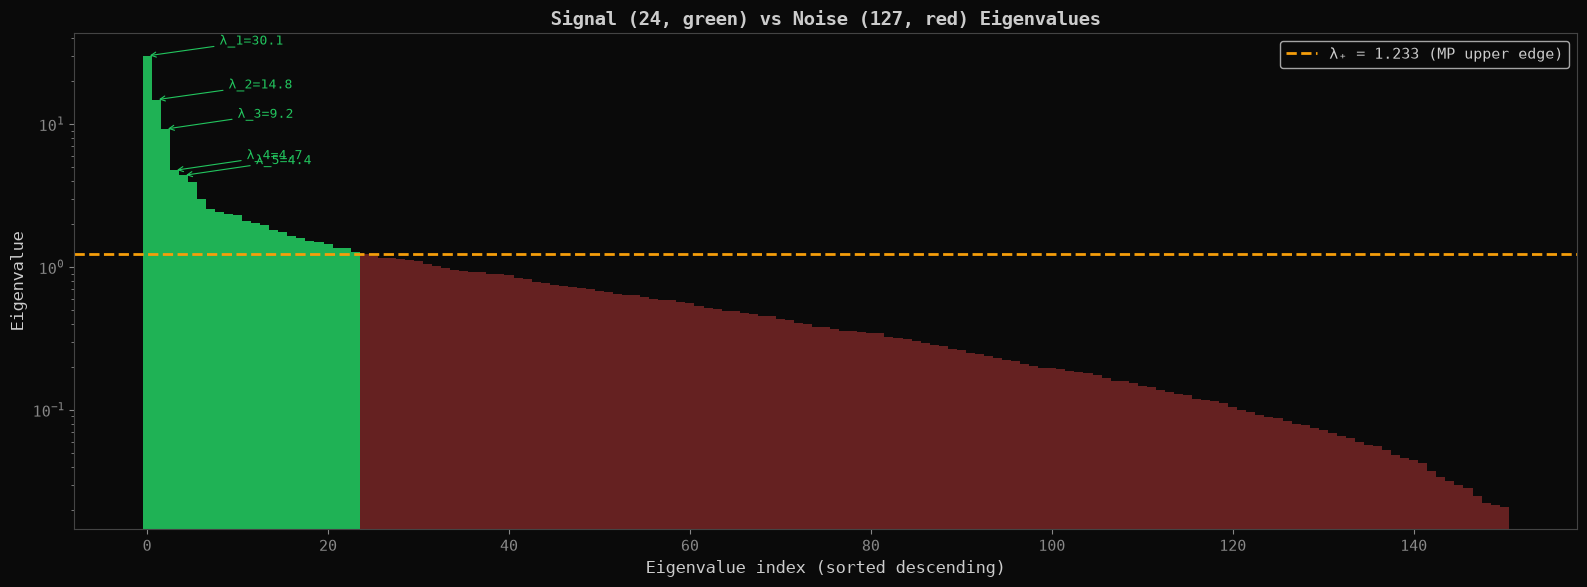

In [11]:
# ─── 6.2 Visualize signal vs noise ───

fig, ax = plt.subplots(figsize=(16, 6))

# Color-coded eigenvalue spectrum
for i, lam in enumerate(eigvals):
    color = COLORS['signal'] if is_signal[i] else COLORS['noise']
    alpha = 0.9 if is_signal[i] else 0.4
    ax.bar(i, lam, color=color, alpha=alpha, width=1.0)

ax.axhline(lam_plus, color=COLORS['accent'], lw=2, ls='--',
           label=f'λ₊ = {lam_plus:.3f} (MP upper edge)')
ax.set_xlabel('Eigenvalue index (sorted descending)')
ax.set_ylabel('Eigenvalue')
ax.set_title(f'Signal ({n_signal}, green) vs Noise ({len(eigvals)-n_signal}, red) Eigenvalues',
             fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=11)

# Annotate first few signal eigenvalues
for i in range(min(5, n_signal)):
    ax.annotate(f'λ_{i+1}={eigvals[i]:.1f}', xy=(i, eigvals[i]),
                xytext=(i+8, eigvals[i]*1.2), fontsize=9, color=COLORS['signal'],
                arrowprops=dict(arrowstyle='->', color=COLORS['signal'], lw=0.8))

plt.tight_layout()
plt.show()


---
<a id="7"></a>
## 7. Covariance Matrix Cleaning

We implement three cleaning methods, each handling the noise eigenvalues differently:

**Method A — Hard Threshold (Laloux et al.):** Replace all noise eigenvalues with their average, preserving the total variance (trace).

**Method B — Targeted Shrinkage:** Shrink noise eigenvalues toward a target while keeping signal eigenvalues intact.

**Method C — Constant Residual:** Replace noise eigenvalues with a single constant chosen to preserve the trace exactly.

All methods preserve the eigenvectors — only the eigenvalues change. This is why the technique is called "eigenvalue cleaning."


In [12]:
# ─── 7.1 Cleaning variants — now in src/eigenrmt/cleaning.py (2.2) ───
# ─── 7.1 Cleaning methods ───

# Apply all three cleaning methods
C_hard, eig_hard, meta_hard = clean_covariance_hard_threshold(eigvals, eigvecs, is_signal)
C_shrink, eig_shrink, meta_shrink = clean_covariance_targeted_shrinkage(eigvals, eigvecs, is_signal, alpha=0.3)
C_const, eig_const, meta_const = clean_covariance_constant_residual(eigvals, eigvecs, is_signal)

# Also get Ledoit-Wolf for comparison
lw = LedoitWolf().fit(demo_window.values)
C_lw = np.corrcoef(demo_window.values.T)  # start from correlation, then LW on returns
lw_cov = LedoitWolf().fit((demo_window.values - demo_window.values.mean(0)) / demo_window.values.std(0))
C_lw = lw_cov.covariance_
eigvals_lw = np.sort(np.linalg.eigvalsh(C_lw))[::-1]

print("Cleaning results:")
for name, eigs, meta in [('Raw sample', eigvals, {}),
                          ('Hard threshold', eig_hard, meta_hard),
                          ('Targeted shrinkage', eig_shrink, meta_shrink),
                          ('Constant residual', eig_const, meta_const),
                          ('Ledoit-Wolf', eigvals_lw, {})]:
    cond = eigs[0] / max(eigs[-1], 1e-10)
    print(f"  {name:<22} condition: {cond:>10.1f}  trace: {eigs.sum():.2f}  min λ: {eigs.min():.4f}")


Cleaning results:
  Raw sample             condition:     1435.2  trace: 151.00  min λ: 0.0210
  Hard threshold         condition:       76.8  trace: 151.00  min λ: 0.3916
  Targeted shrinkage     condition:      107.3  trace: 151.00  min λ: 0.2804
  Constant residual      condition:       76.8  trace: 151.00  min λ: 0.3916
  Ledoit-Wolf            condition:      207.3  trace: 151.00  min λ: 0.1296


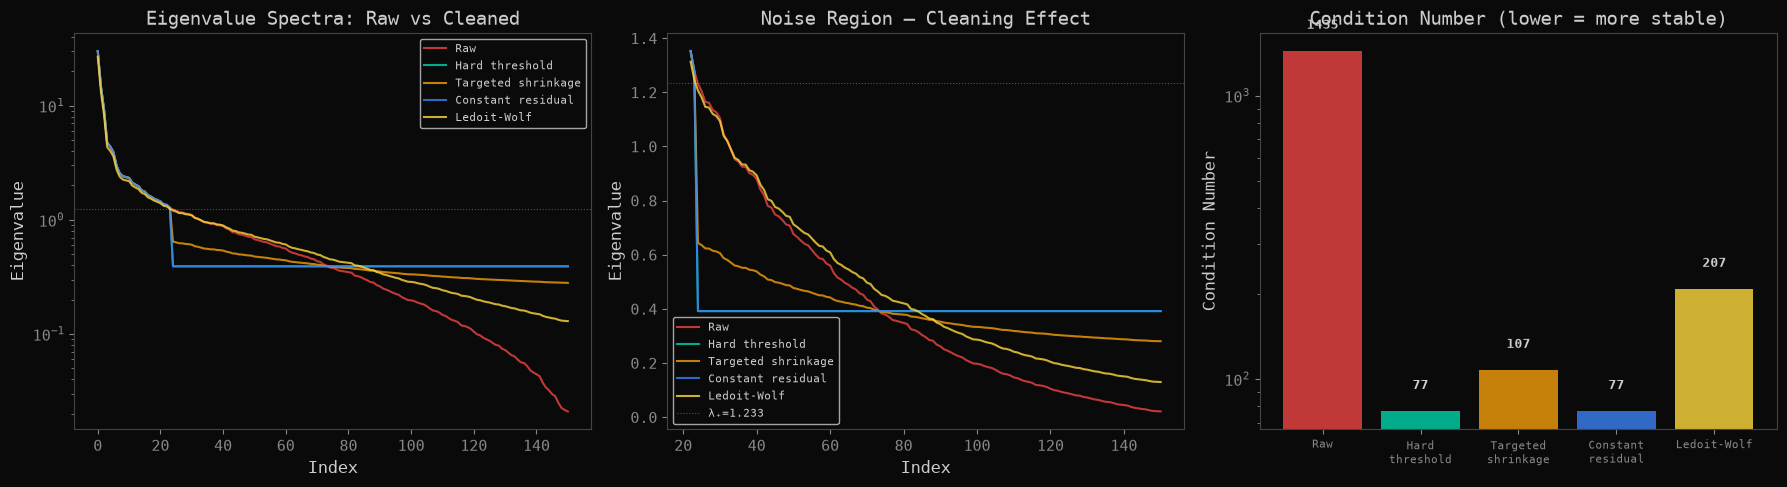


→ RMT cleaning dramatically reduces the condition number,
  making matrix inversion (needed for min-var portfolios) much more stable.


In [13]:
# ─── 7.2 Visualize cleaning effect ───

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Eigenvalue comparison
ax = axes[0]
methods = [('Raw', eigvals, COLORS['noise']),
           ('Hard threshold', eig_hard, COLORS['rmt_clean']),
           ('Targeted shrinkage', eig_shrink, COLORS['accent']),
           ('Constant residual', eig_const, COLORS['mp_theory']),
           ('Ledoit-Wolf', eigvals_lw, COLORS['ledoit_wolf'])]

for name, eigs, color in methods:
    ax.plot(range(len(eigs)), eigs, lw=1.5, alpha=0.8, color=color, label=name)

ax.axhline(lam_plus, color='white', lw=0.8, ls=':', alpha=0.3)
ax.set_xlabel('Index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Spectra: Raw vs Cleaned')
ax.set_yscale('log')
ax.legend(fontsize=8)

# (b) Zoom into noise region
ax = axes[1]
start_idx = max(0, n_signal - 2)
for name, eigs, color in methods:
    ax.plot(range(start_idx, len(eigs)), eigs[start_idx:], lw=1.5, alpha=0.8, color=color, label=name)
ax.axhline(lam_plus, color='white', lw=0.8, ls=':', alpha=0.3, label=f'λ₊={lam_plus:.3f}')
ax.set_xlabel('Index')
ax.set_ylabel('Eigenvalue')
ax.set_title('Noise Region — Cleaning Effect')
ax.legend(fontsize=8)

# (c) Condition number improvement
ax = axes[2]
cond_numbers = {name: eigs[0]/max(eigs[-1], 1e-10) for name, eigs, _ in methods}
bars = ax.bar(range(len(cond_numbers)), list(cond_numbers.values()),
              color=[c for _, _, c in methods], alpha=0.8)
ax.set_xticks(range(len(cond_numbers)))
ax.set_xticklabels([n.replace(' ', '\n') for n in cond_numbers.keys()], fontsize=8)
ax.set_ylabel('Condition Number')
ax.set_title('Condition Number (lower = more stable)')
ax.set_yscale('log')

for bar, val in zip(bars, cond_numbers.values()):
    ax.text(bar.get_x() + bar.get_width()/2, val*1.2, f'{val:.0f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n→ RMT cleaning dramatically reduces the condition number,")
print("  making matrix inversion (needed for min-var portfolios) much more stable.")


---
<a id="8"></a>
## 8. Eigenportfolio Construction & Interpretation

An **eigenportfolio** is a portfolio whose weights are proportional to an eigenvector. The first eigenportfolio (largest eigenvalue) is approximately the market portfolio. Higher eigenportfolios capture sector, style, or other structural factors — discovered purely from the data, without imposing any economic model.


In [14]:
# ─── 8.1 Build and interpret eigenportfolios ───

# P2-4 fixed in src: eigvals passed explicitly, no enclosing-scope reads
eigenportfolios = build_eigenportfolios(eigvals, eigvecs, is_signal, asset_names)

# Print first 5 eigenportfolios
for ep in eigenportfolios[:5]:
    print(f"\n{'='*60}")
    print(f"Eigenportfolio {ep['index']} — {ep['explained_var']:.1%} of variance")
    print(f"{'='*60}")
    print(f"  Top 5 LONG:  {[(n, f'{w:.3f}') for n, w in ep['long_assets'][:5]]}")
    print(f"  Top 5 SHORT: {[(n, f'{w:.3f}') for n, w in ep['short_assets'][:5]]}")



Eigenportfolio 1 — 19.9% of variance
  Top 5 LONG:  []
  Top 5 SHORT: [('USB', '-0.011'), ('BLK', '-0.011'), ('ITW', '-0.011'), ('PNC', '-0.011'), ('TFC', '-0.011')]

Eigenportfolio 2 — 9.8% of variance
  Top 5 LONG:  [('AMAT', '0.018'), ('NVDA', '0.016'), ('QCOM', '0.016'), ('MU', '0.015'), ('AMD', '0.013')]
  Top 5 SHORT: [('SO', '-0.018'), ('AEP', '-0.017'), ('DUK', '-0.017'), ('WEC', '-0.017'), ('KO', '-0.016')]

Eigenportfolio 3 — 6.1% of variance
  Top 5 LONG:  [('ISRG', '0.018'), ('SYK', '0.016'), ('MSFT', '0.015'), ('COST', '0.014'), ('EW', '0.013')]
  Top 5 SHORT: [('COP', '-0.022'), ('XOM', '-0.020'), ('EOG', '-0.020'), ('HAL', '-0.019'), ('DVN', '-0.018')]

Eigenportfolio 4 — 3.1% of variance
  Top 5 LONG:  [('WFC', '0.022'), ('PNC', '0.020'), ('JPM', '0.019'), ('TFC', '0.017'), ('BAC', '0.016')]
  Top 5 SHORT: [('OXY', '-0.026'), ('DVN', '-0.024'), ('EOG', '-0.022'), ('XOM', '-0.022'), ('COP', '-0.021')]

Eigenportfolio 5 — 2.9% of variance
  Top 5 LONG:  [('TMO', '0.020')

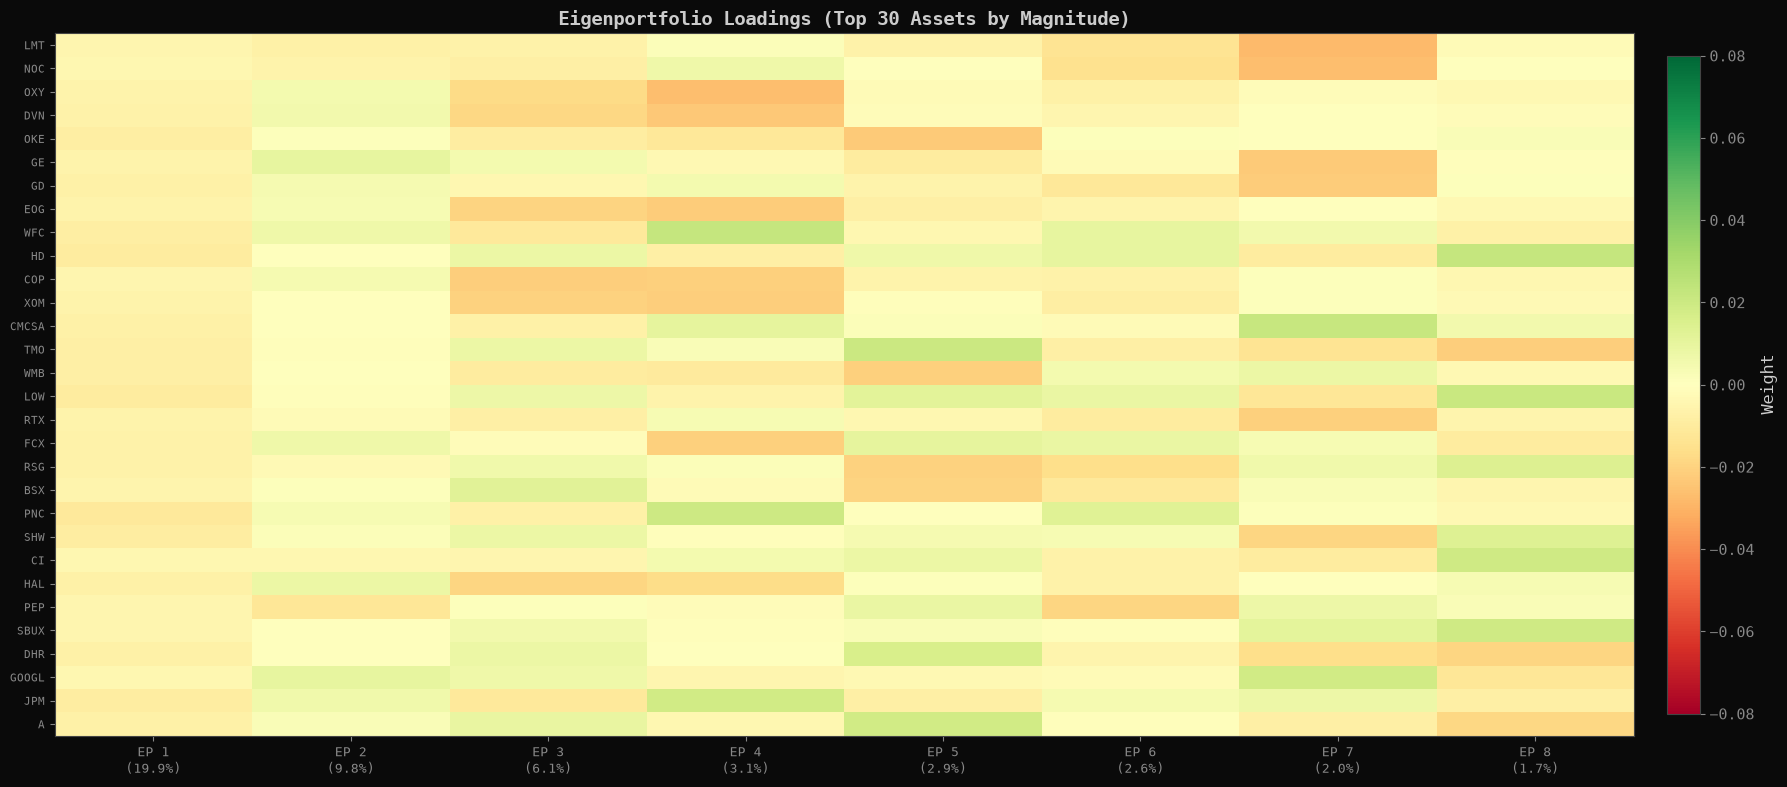

→ EP1 (market): roughly uniform positive loadings across all assets.
  EP2+: sector and style contrasts emerge from pure statistical decomposition.
  No economic model was imposed — these factors are data-driven.


In [15]:
# ─── 8.2 Eigenportfolio composition heatmap ───

n_show = min(8, n_signal)
fig, ax = plt.subplots(figsize=(18, 8))

# Build weight matrix for top eigenportfolios
W_matrix = np.column_stack([eigenportfolios[k]['weights'] for k in range(n_show)])

# Show top 30 assets by absolute loading on first eigenvector
top_assets_idx = np.argsort(np.abs(W_matrix).max(axis=1))[::-1][:30]

heatmap_data = W_matrix[top_assets_idx, :]
heatmap_labels = [asset_names[i] for i in top_assets_idx]

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=-0.08, vmax=0.08)
ax.set_xticks(range(n_show))
ax.set_xticklabels([f'EP {k+1}\n({eigenportfolios[k]["explained_var"]:.1%})' for k in range(n_show)], fontsize=9)
ax.set_yticks(range(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels, fontsize=8)
ax.set_title('Eigenportfolio Loadings (Top 30 Assets by Magnitude)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label='Weight')

plt.tight_layout()
plt.show()

print("→ EP1 (market): roughly uniform positive loadings across all assets.")
print("  EP2+: sector and style contrasts emerge from pure statistical decomposition.")
print("  No economic model was imposed — these factors are data-driven.")


---
<a id="9"></a>
## 9. Portfolio Construction: Min-Var with Cleaned Covariance

<a id="10"></a>
## 10. Benchmark Strategies

We build **minimum variance portfolios** using four different covariance inputs, plus two naive benchmarks. The minimum variance portfolio is the ideal test case for covariance quality because it depends *only* on the covariance matrix — no return forecast needed.

$$w_{MV} = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^T \Sigma^{-1} \mathbf{1}}$$


In [16]:
# ─── 9.1 Min-var solver (constrained) ───

print("Portfolio construction via src/eigenrmt/backtest.py.")


Portfolio construction via src/eigenrmt/backtest.py.


---
<a id="11"></a>
## 11. Rolling Backtest Engine

We run a walk-forward backtest that, at each monthly rebalancing date:
1. Computes eigendecomposition from trailing 252-day window
2. Fits Marchenko–Pastur and classifies signal/noise
3. Cleans the covariance using each method
4. Builds min-var portfolios from each covariance input
5. Tracks forward returns, costs, and turnover


In [17]:
# ─── 11.1 Full rolling backtest ───

# Also get SPY
SPY_CACHE = DATA_DIR / 'p2_spy_2005_2024.parquet'
if SPY_CACHE.exists():
    spy = pd.read_parquet(SPY_CACHE).squeeze('columns')
else:
    spy = yf.download('SPY', start=CONFIG['start_date'], end=CONFIG['end_date'],
                       auto_adjust=True, progress=False)['Close']
    spy.to_parquet(SPY_CACHE)
    spy = spy.squeeze('columns')  # yfinance returns a 1-col DataFrame; downstream needs a Series
spy_ret = np.log(spy / spy.shift(1)).dropna()
spy_ret_simple = np.expm1(spy_ret)  # G-2: benchmark series in SIMPLE returns for metrics

# Run the full backtest
print("=" * 60)
print("RUNNING RMT BACKTEST (all strategies simultaneously)")
print("=" * 60)
t0 = time.time()
bt_results = run_rmt_backtest(returns, CONFIG, verbose=True)
bt_results['sp500'] = {'returns': spy_ret_simple, 'turnover': [], 'costs': [], 'n_signal': [], 'condition': []}
print(f"\nCompleted in {time.time()-t0:.1f}s")


RUNNING RMT BACKTEST (all strategies simultaneously)


  Rebalance 1/217 at 2006-11-17 | signals: 17


  Rebalance 21/217 at 2008-07-23 | signals: 25


  Rebalance 41/217 at 2010-03-24 | signals: 29


  Rebalance 61/217 at 2011-11-18 | signals: 30


...

  Rebalance 141/217 at 2018-07-26 | signals: 29


  Rebalance 161/217 at 2020-03-27 | signals: 42


  Rebalance 181/217 at 2021-11-24 | signals: 35


  Rebalance 201/217 at 2023-07-31 | signals: 32



Completed in 81.1s


---
<a id="12"></a>
## 12. Performance Evaluation


In [18]:
# ─── 12.1 Metrics computation ───

# ROADMAP 2.1: metrics via common/metrics.py — key names match, pure drop-in.
from common.metrics import summary as compute_metrics

# Compute metrics for all strategies, all periods
strategy_labels = {
    'rmt_hard': 'RMT Hard Threshold', 'rmt_shrink': 'RMT Targeted Shrinkage',
    'rmt_const': 'RMT Constant Residual', 'ledoit_wolf': 'Ledoit-Wolf Min-Var',
    'raw_sample': 'Raw Sample Min-Var', 'equal_weight': 'Equal Weight (1/N)',
    'sp500': 'S&P 500 (Buy & Hold)',
}

all_metrics = {}
for strat, data in bt_results.items():
    ret = data['returns']
    all_metrics[strat] = {}
    
    for label, mask_fn in [('Full', lambda r: r),
                            ('IS', lambda r: r[r.index <= CONFIG['is_end']]),
                            ('OOS', lambda r: r[r.index >= CONFIG['oos_start']])]:
        all_metrics[strat][label] = compute_metrics(mask_fn(ret))
    
    # Add turnover info
    if data.get('turnover'):
        all_metrics[strat]['avg_turnover'] = np.mean(data['turnover'])
        all_metrics[strat]['total_cost'] = sum(data['costs'])
    else:
        all_metrics[strat]['avg_turnover'] = 0
        all_metrics[strat]['total_cost'] = 0

# ── PRINT COMPARISON TABLE ──
for period in ['Full', 'IS', 'OOS']:
    print(f"\n{'='*110}")
    print(f"PERFORMANCE COMPARISON — {period}")
    print(f"{'='*110}")
    print(f"{'Strategy':<26} {'Return':>8} {'Vol':>8} {'Sharpe':>8} {'SR 95% CI':>18} {'MaxDD':>8} {'Sortino':>8} {'CVaR95':>8}")
    print("-" * 110)
    
    for strat in ['rmt_hard', 'rmt_shrink', 'rmt_const', 'ledoit_wolf', 'raw_sample', 'equal_weight', 'sp500']:
        m = all_metrics.get(strat, {}).get(period, {})
        if not m or np.isnan(m.get('ann_ret', np.nan)):
            continue
        ci = f"[{m.get('sharpe_ci_lo',0):.2f}, {m.get('sharpe_ci_hi',0):.2f}]"
        print(f"{strategy_labels.get(strat, strat):<26} "
              f"{m['ann_ret']:>7.2%} {m['ann_vol']:>7.2%} {m['sharpe']:>8.3f} {ci:>18} "
              f"{m['max_dd']:>7.2%} {m['sortino']:>8.3f} {m['cvar95']:>7.4f}")

# Turnover summary
print(f"\n{'Strategy':<26} {'Avg Turnover':>14} {'Total Cost (bps)':>18} {'Non-opt solves':>16}")
print("-" * 78)
for strat in ['rmt_hard', 'rmt_shrink', 'rmt_const', 'ledoit_wolf', 'raw_sample', 'equal_weight']:
    m = all_metrics.get(strat, {})
    statuses = bt_results[strat].get('solve_status', [])
    n_bad = sum(1 for s in statuses if s not in ('optimal', 'optimal_inaccurate'))
    bad = f"{n_bad}/{len(statuses)}" if statuses else "n/a"
    print(f"{strategy_labels.get(strat, strat):<26} {m.get('avg_turnover',0):>14.4f} {m.get('total_cost',0)*10000:>17.1f} {bad:>16}")



PERFORMANCE COMPARISON — Full
Strategy                     Return      Vol   Sharpe          SR 95% CI    MaxDD  Sortino   CVaR95
--------------------------------------------------------------------------------------------------------------
RMT Hard Threshold          10.75%  13.66%    0.604       [0.10, 1.11] -38.05%    0.737 -0.0209
RMT Targeted Shrinkage      10.76%  13.66%    0.604       [0.10, 1.11] -38.00%    0.737 -0.0209
RMT Constant Residual       10.75%  13.66%    0.604       [0.10, 1.11] -38.05%    0.737 -0.0209
Ledoit-Wolf Min-Var         10.80%  13.65%    0.608       [0.11, 1.11] -37.91%    0.741 -0.0208
Raw Sample Min-Var          10.78%  13.66%    0.606       [0.10, 1.11] -37.93%    0.739 -0.0208
Equal Weight (1/N)          14.88%  19.06%    0.650       [0.14, 1.16] -48.07%    0.800 -0.0296
S&P 500 (Buy & Hold)        11.65%  19.04%    0.481       [0.02, 0.94] -55.19%    0.585 -0.0293

PERFORMANCE COMPARISON — IS
Strategy                     Return      Vol   Sharpe    

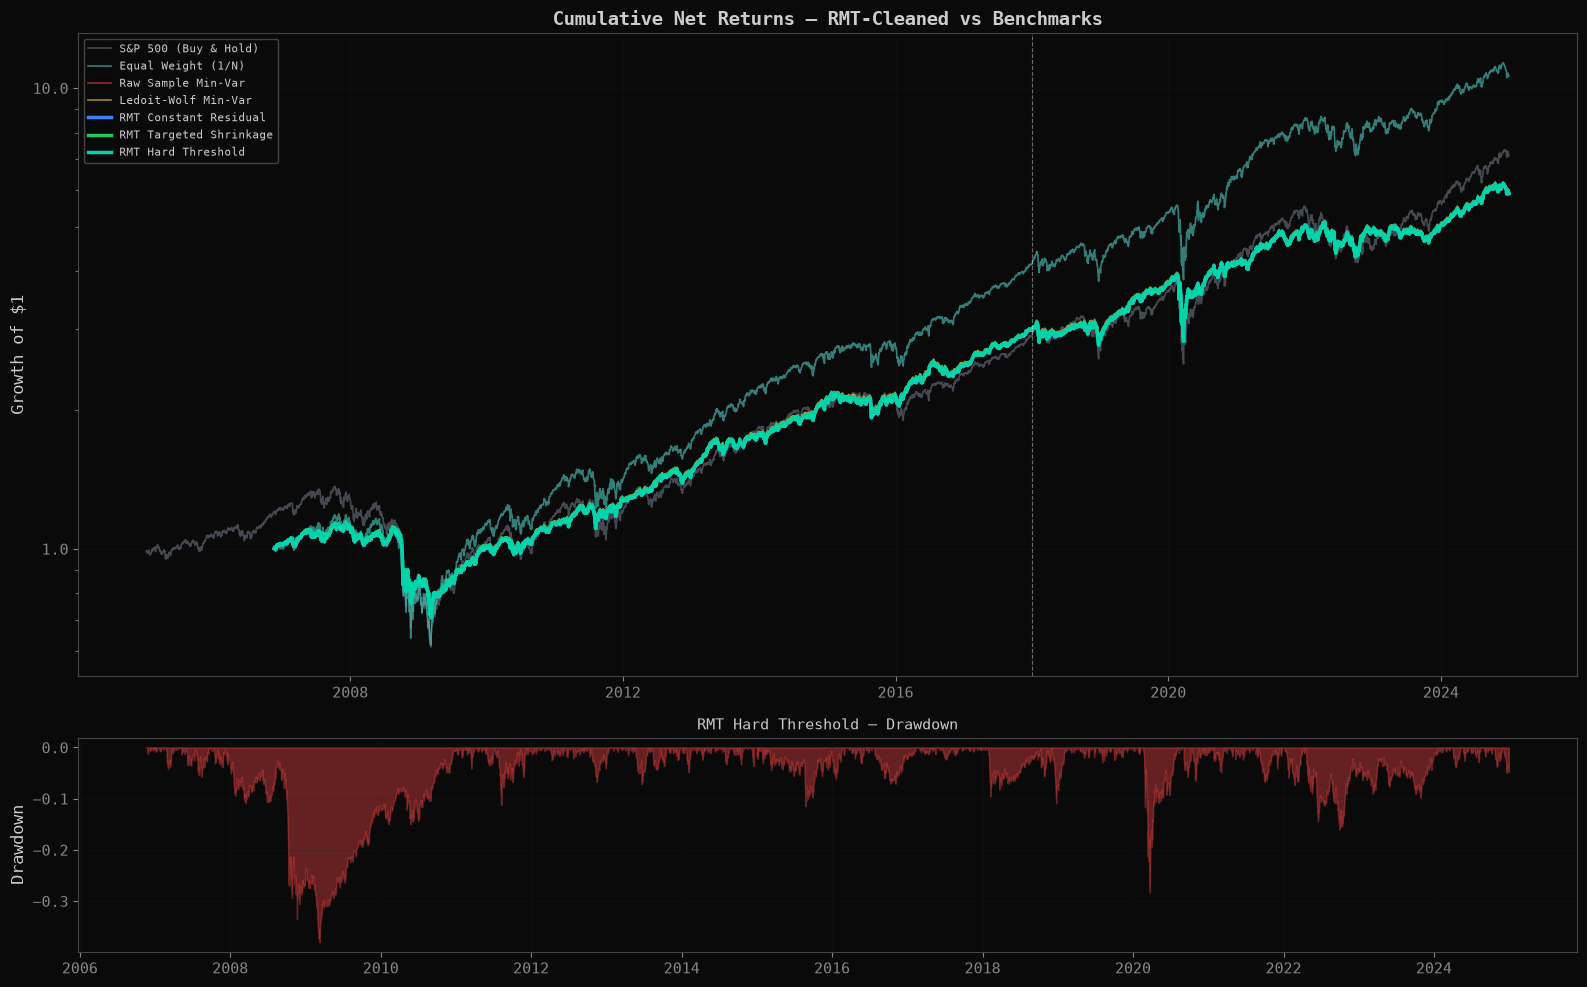

In [19]:
# ─── 12.2 Cumulative return plot ───

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

color_map = {
    'rmt_hard': COLORS['rmt_clean'], 'rmt_shrink': COLORS['signal'],
    'rmt_const': COLORS['mp_theory'], 'ledoit_wolf': COLORS['ledoit_wolf'],
    'raw_sample': COLORS['noise'], 'equal_weight': COLORS['equal_wt'],
    'sp500': COLORS['sp500'],
}

# Cumulative returns
ax = axes[0]
for strat in ['sp500', 'equal_weight', 'raw_sample', 'ledoit_wolf', 'rmt_const', 'rmt_shrink', 'rmt_hard']:
    ret = bt_results[strat]['returns']
    cum = (1 + ret).cumprod()
    lw = 2.5 if strat.startswith('rmt') else 1.2
    alpha = 1.0 if strat.startswith('rmt') else 0.6
    ax.plot(cum.index, cum.values, color=color_map[strat], lw=lw, alpha=alpha,
            label=strategy_labels[strat])

ax.axvline(pd.Timestamp(CONFIG['is_end']), color='white', lw=0.8, ls='--', alpha=0.4)
ax.set_title('Cumulative Net Returns — RMT-Cleaned vs Benchmarks', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.legend(loc='upper left', fontsize=8, framealpha=0.3)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax.grid(True, alpha=0.2)

# Drawdown (RMT hard threshold)
ax = axes[1]
ret = bt_results['rmt_hard']['returns']
cum = (1 + ret).cumprod()
dd = (cum - cum.cummax()) / cum.cummax()
ax.fill_between(dd.index, 0, dd.values, color=COLORS['noise'], alpha=0.4)
ax.set_title('RMT Hard Threshold — Drawdown', fontsize=11)
ax.set_ylabel('Drawdown')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


---
<a id="13"></a>
## 13. Sensitivity Analysis

We test sensitivity to: (a) the cleaning method, (b) the effective $q$ ratio (by varying $n$ and $T$), and (c) the number of signal eigenvalues over time — which tells us how the dimensionality of the market changes.


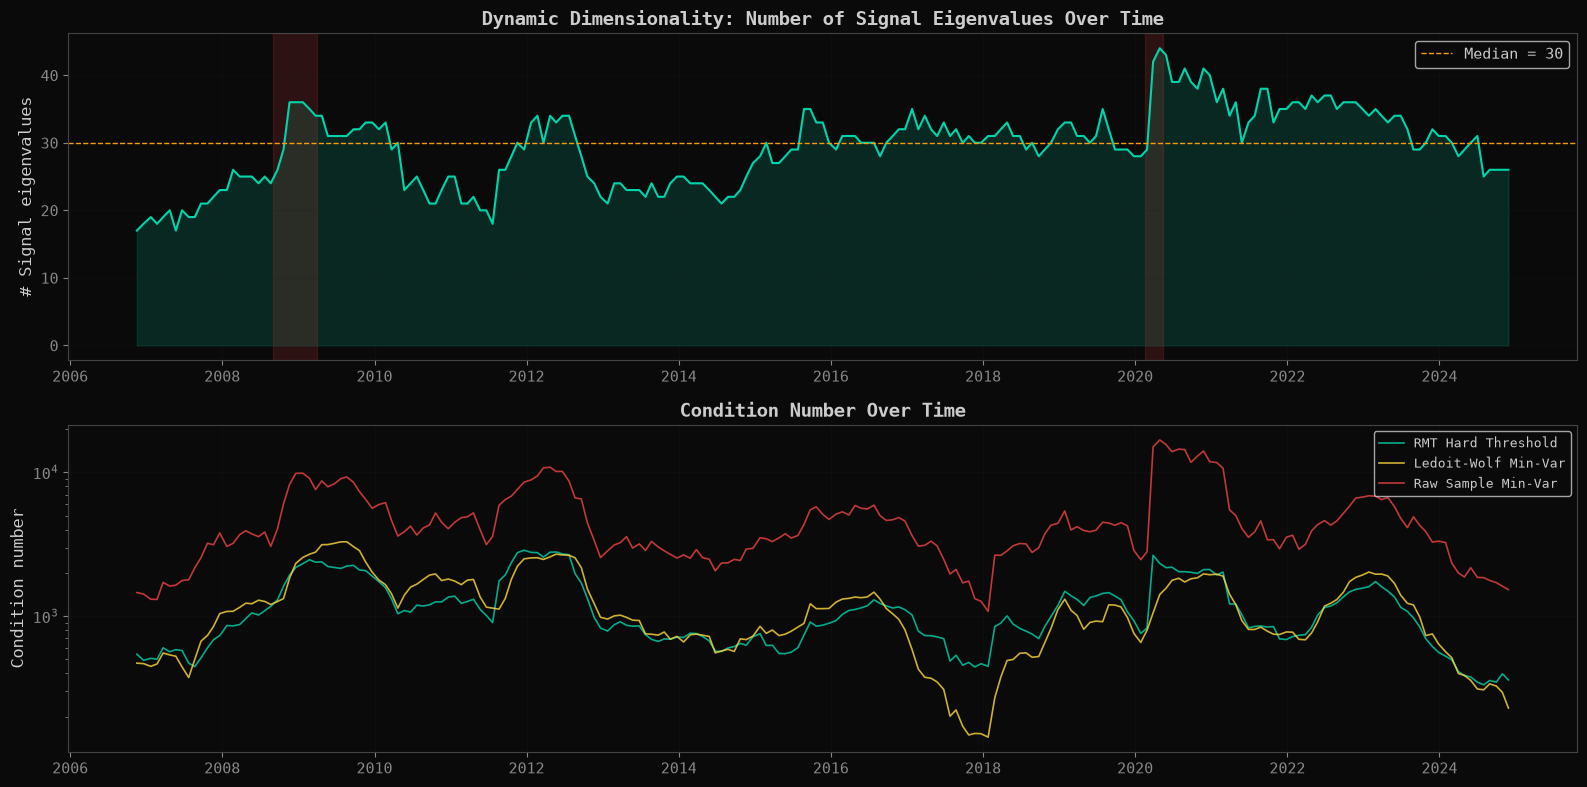

→ During crises (GFC, COVID), correlations spike and dimensionality collapses
  (fewer signal eigenvalues). This is a signature of 'risk-on/risk-off' regimes.


In [20]:
# ─── 13.1 Dynamic dimensionality — number of signals over time ───

# Track n_signal from the backtest
n_signal_over_time = []
for strat_data in [bt_results['rmt_hard']]:
    if strat_data.get('n_signal'):
        # Approximate dates from rebalancing frequency
        rebal_dates_approx = returns.index[CONFIG['lookback_days']::CONFIG['rebal_frequency']]
        for i, ns in enumerate(strat_data['n_signal']):
            if i < len(rebal_dates_approx):
                n_signal_over_time.append({'date': rebal_dates_approx[i], 'n_signal': ns})

if n_signal_over_time:
    nsig_df = pd.DataFrame(n_signal_over_time).set_index('date')
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [1, 1]})
    
    # (a) Number of signal eigenvalues over time
    ax = axes[0]
    ax.plot(nsig_df.index, nsig_df['n_signal'], color=COLORS['rmt_clean'], lw=1.5)
    ax.fill_between(nsig_df.index, 0, nsig_df['n_signal'].values, alpha=0.15, color=COLORS['rmt_clean'])
    ax.set_title('Dynamic Dimensionality: Number of Signal Eigenvalues Over Time', fontweight='bold')
    ax.set_ylabel('# Signal eigenvalues')
    ax.axhline(nsig_df['n_signal'].median(), color=COLORS['accent'], lw=1, ls='--',
               label=f'Median = {nsig_df["n_signal"].median():.0f}')
    
    for label, start, end in [('GFC', '2008-09-01', '2009-03-31'), ('COVID', '2020-02-15', '2020-05-15')]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.15, color=COLORS['noise'])
    ax.legend()
    ax.grid(True, alpha=0.2)
    
    # (b) Condition number over time for each method
    ax = axes[1]
    for strat, color in [('rmt_hard', COLORS['rmt_clean']), ('ledoit_wolf', COLORS['ledoit_wolf']),
                          ('raw_sample', COLORS['noise'])]:
        conds = bt_results[strat].get('condition', [])
        if conds:
            dates = rebal_dates_approx[:len(conds)]
            ax.plot(dates, conds, lw=1.2, color=color, label=strategy_labels[strat], alpha=0.8)
    
    ax.set_title('Condition Number Over Time', fontweight='bold')
    ax.set_ylabel('Condition number')
    ax.set_yscale('log')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    print("→ During crises (GFC, COVID), correlations spike and dimensionality collapses")
    print("  (fewer signal eigenvalues). This is a signature of 'risk-on/risk-off' regimes.")
else:
    print("No dynamic signal data available — check backtest output.")


In [21]:
# ─── 13.2 Q-ratio sensitivity analysis ───
# Test: how does performance change as we vary the number of assets?

print("Q-ratio sensitivity (subset analysis):")
print(f"{'n_assets':>10} {'q=n/T':>8} {'n_signal':>10} {'Cond (raw)':>12} {'Cond (RMT)':>12}")
print("-" * 55)

for n_test in [50, 100, 150, n_assets]:
    # Use last window, subset of assets
    sub_rets = returns.iloc[-CONFIG['lookback_days']:, :n_test]
    if sub_rets.shape[1] < n_test:
        continue
    
    ev, evec, C, _ = compute_eigen(sub_rets)
    q_test = n_test / CONFIG['lookback_days']
    is_sig_test, _, n_sig_test = classify_eigenvalues(ev, q_test)
    
    # Clean
    C_clean, eig_clean, _ = clean_covariance_hard_threshold(ev, evec, is_sig_test)
    cond_raw = ev[0] / max(ev[-1], 1e-10)
    cond_clean = eig_clean[0] / max(eig_clean[-1], 1e-10)
    
    print(f"{n_test:>10} {q_test:>8.3f} {n_sig_test:>10} {cond_raw:>12.0f} {cond_clean:>12.0f}")

print("\n→ As q → 1, more eigenvalues are noise and RMT cleaning has greater impact.")


Q-ratio sensitivity (subset analysis):
  n_assets    q=n/T   n_signal   Cond (raw)   Cond (RMT)
-------------------------------------------------------
        50    0.198         12          133           30
       100    0.397         21          371           52
       150    0.595         24         1420           76
       151    0.599         24         1435           77

→ As q → 1, more eigenvalues are noise and RMT cleaning has greater impact.


---
<a id="14"></a>
## 14. Regime-Conditioned Evaluation


In [22]:
# ─── 14.1 Regime classification and conditioned performance ───

spy_monthly = spy_ret.resample('ME').sum()
regime_labels = spy_monthly.apply(lambda x: 'Bull' if x > 0.02 else ('Bear' if x < -0.02 else 'Sideways'))

print(f"Regime distribution: {dict(regime_labels.value_counts())}")

regime_metrics = {}
for strat in ['rmt_hard', 'rmt_shrink', 'ledoit_wolf', 'raw_sample', 'equal_weight', 'sp500']:
    ret = bt_results[strat]['returns']
    monthly_regime = regime_labels.reindex(ret.index, method='ffill').fillna('Sideways')
    
    regime_metrics[strat] = {}
    for regime in ['Bull', 'Bear', 'Sideways']:
        mask = monthly_regime == regime
        if mask.sum() > 10:
            regime_metrics[strat][regime] = compute_metrics(ret[mask])

# Regime comparison table
print(f"\n{'='*80}")
print(f"REGIME-CONDITIONED NET SHARPE RATIOS")
print(f"{'='*80}")
print(f"{'Strategy':<26} {'Bull':>10} {'Bear':>10} {'Sideways':>10}")
print("-" * 58)

for strat in ['rmt_hard', 'rmt_shrink', 'ledoit_wolf', 'raw_sample', 'equal_weight', 'sp500']:
    vals = []
    for regime in ['Bull', 'Bear', 'Sideways']:
        v = regime_metrics.get(strat, {}).get(regime, {}).get('sharpe', np.nan)
        vals.append(v)
    print(f"{strategy_labels.get(strat, strat):<26} {vals[0]:>10.3f} {vals[1]:>10.3f} {vals[2]:>10.3f}")


Regime distribution: {'Bull': np.int64(102), 'Sideways': np.int64(89), 'Bear': np.int64(49)}

REGIME-CONDITIONED NET SHARPE RATIOS
Strategy                         Bull       Bear   Sideways
----------------------------------------------------------
RMT Hard Threshold              0.773      0.634      0.506
RMT Targeted Shrinkage          0.779      0.632      0.504
Ledoit-Wolf Min-Var             0.788      0.631      0.506
Raw Sample Min-Var              0.788      0.631      0.500
Equal Weight (1/N)              0.877      0.746      0.417
S&P 500 (Buy & Hold)            0.661      0.640      0.224


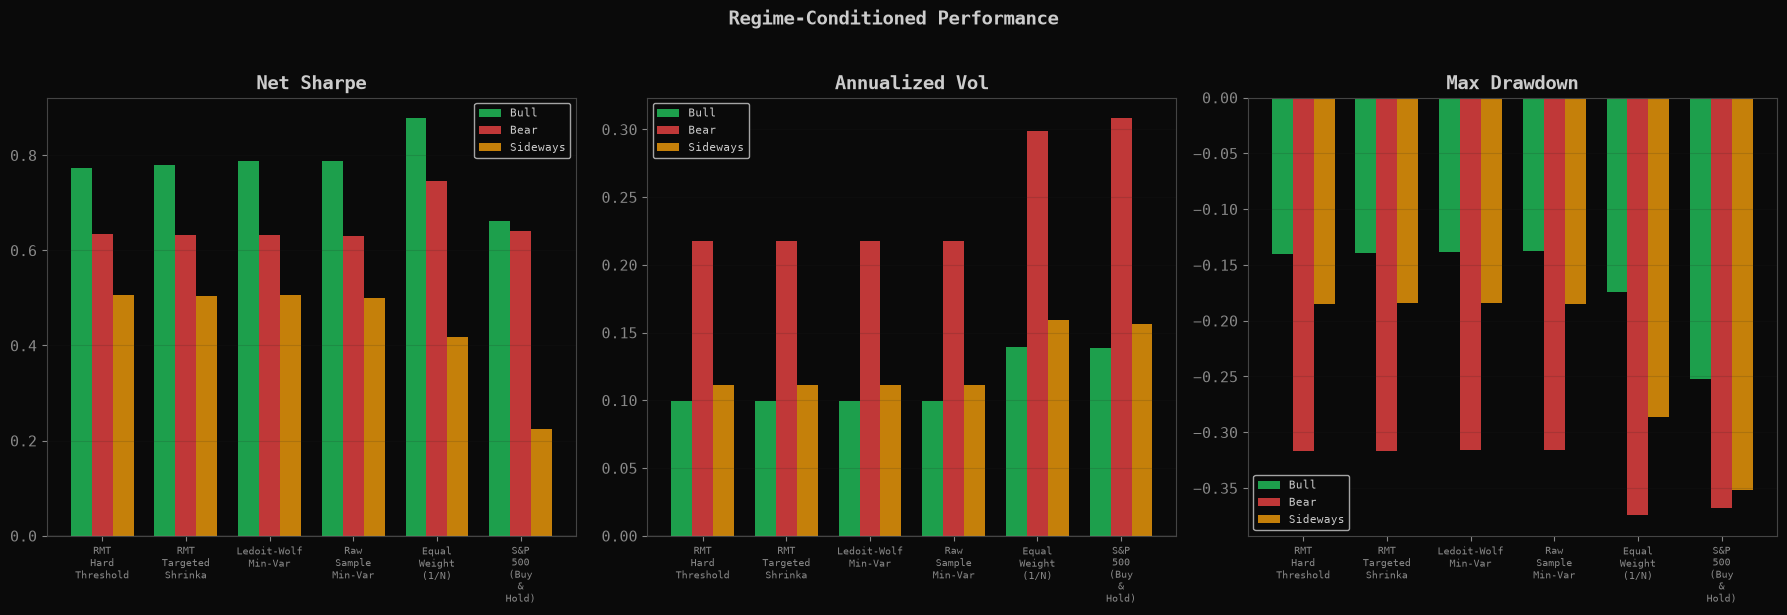

In [23]:
# ─── 14.2 Regime bar chart ───

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
regime_colors = {'Bull': '#22c55e', 'Bear': '#ef4444', 'Sideways': '#f59e0b'}
strat_order = ['rmt_hard', 'rmt_shrink', 'ledoit_wolf', 'raw_sample', 'equal_weight', 'sp500']

for ax, metric, label in zip(axes, ['sharpe', 'ann_vol', 'max_dd'],
                               ['Net Sharpe', 'Annualized Vol', 'Max Drawdown']):
    x = np.arange(len(strat_order))
    width = 0.25
    for k, regime in enumerate(['Bull', 'Bear', 'Sideways']):
        vals = [regime_metrics.get(s, {}).get(regime, {}).get(metric, 0) or 0 for s in strat_order]
        ax.bar(x + (k-1)*width, vals, width, label=regime, color=regime_colors[regime], alpha=0.8)
    
    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n')[:20] for s in strat_order], fontsize=7)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.15, axis='y')
    ax.axhline(0, color='white', lw=0.3, alpha=0.3)

plt.suptitle('Regime-Conditioned Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
<a id="15"></a>
## 15. Failure Mode Analysis


In [24]:
# ─── 15.1 Honesty check: RMT vs Ledoit-Wolf ───

print("=" * 60)
print("HONEST ASSESSMENT: RMT-CLEANED vs LEDOIT-WOLF")
print("=" * 60)

rmt_oos = all_metrics['rmt_hard'].get('OOS', {})
lw_oos = all_metrics['ledoit_wolf'].get('OOS', {})
ew_oos = all_metrics['equal_weight'].get('OOS', {})
raw_oos = all_metrics['raw_sample'].get('OOS', {})

print(f"\nOOS Net Sharpe Ratios:")
print(f"  RMT Hard Threshold: {rmt_oos.get('sharpe', 0):.3f}  CI: [{rmt_oos.get('sharpe_ci_lo', 0):.3f}, {rmt_oos.get('sharpe_ci_hi', 0):.3f}]")
print(f"  Ledoit-Wolf:        {lw_oos.get('sharpe', 0):.3f}  CI: [{lw_oos.get('sharpe_ci_lo', 0):.3f}, {lw_oos.get('sharpe_ci_hi', 0):.3f}]")
print(f"  Raw Sample:         {raw_oos.get('sharpe', 0):.3f}")
print(f"  Equal Weight:       {ew_oos.get('sharpe', 0):.3f}")

print(f"\nOOS Realized Volatility:")
print(f"  RMT Hard Threshold: {rmt_oos.get('ann_vol', 0):.2%}")
print(f"  Ledoit-Wolf:        {lw_oos.get('ann_vol', 0):.2%}")
print(f"  Raw Sample:         {raw_oos.get('ann_vol', 0):.2%}")

rmt_sr = rmt_oos.get('sharpe', 0)
lw_sr = lw_oos.get('sharpe', 0)

if rmt_sr > lw_sr:
    if rmt_oos.get('sharpe_ci_lo', 0) > lw_sr:
        print("\n→ RMT cleaning significantly outperforms Ledoit-Wolf (non-overlapping CIs).")
    else:
        print("\n→ RMT cleaning shows higher point-estimate Sharpe than Ledoit-Wolf,")
        print("  but the confidence intervals overlap. The advantage is suggestive, not definitive.")
else:
    print("\n→ Ledoit-Wolf matches or beats RMT cleaning. This is an honest finding —")
    print("  the simpler method may be sufficient for this universe and period.")
    print("  RMT provides deeper structural insight even if portfolio performance is similar.")

# Key structural insight regardless of performance
print(f"\nStructural insight (always valid regardless of portfolio performance):")
print(f"  Only {n_signal} out of {n_assets} eigenvalues carry real information.")
print(f"  The remaining {n_assets - n_signal} ({(n_assets-n_signal)/n_assets:.0%}) are noise.")
print(f"  This is the fundamental takeaway of the project.")


HONEST ASSESSMENT: RMT-CLEANED vs LEDOIT-WOLF

OOS Net Sharpe Ratios:
  RMT Hard Threshold: 0.579  CI: [-0.222, 1.381]
  Ledoit-Wolf:        0.581  CI: [-0.221, 1.383]
  Raw Sample:         0.580
  Equal Weight:       0.697

OOS Realized Volatility:
  RMT Hard Threshold: 14.31%
  Ledoit-Wolf:        14.31%
  Raw Sample:         14.32%

→ Ledoit-Wolf matches or beats RMT cleaning. This is an honest finding —
  the simpler method may be sufficient for this universe and period.
  RMT provides deeper structural insight even if portfolio performance is similar.

Structural insight (always valid regardless of portfolio performance):
  Only 24 out of 151 eigenvalues carry real information.
  The remaining 127 (84%) are noise.
  This is the fundamental takeaway of the project.


In [25]:
# ─── 16.1 Survivorship bias diagnostic — the decay table (G-3) ───
# SPY (cap-weight) and RSP (equal-weight S&P 500) are investable,
# survivorship-free benchmarks. Survivors-EW minus RSP isolates SELECTION
# bias from the equal-weight factor; the IS→OOS decay is the survivorship
# signature (2024 selection foreknowledge is greatest about the earliest
# years and expires approaching the selection date).

RSP_CACHE = DATA_DIR / 'p2_rsp_2005_2024.parquet'
if RSP_CACHE.exists():
    rsp = pd.read_parquet(RSP_CACHE).squeeze('columns')
else:
    rsp = yf.download('RSP', start=CONFIG['start_date'], end=CONFIG['end_date'],
                      auto_adjust=True, progress=False)['Close']
    rsp.to_parquet(RSP_CACHE)
    rsp = rsp.squeeze('columns')
rsp_ret_simple = np.expm1(np.log(rsp / rsp.shift(1)).dropna())

ew_ret = bt_results['equal_weight']['returns']
common_idx = ew_ret.index.intersection(rsp_ret_simple.index)
series = {
    'Survivors EW': ew_ret.reindex(common_idx),
    'SPY': bt_results['sp500']['returns'].reindex(common_idx),
    'RSP': rsp_ret_simple.reindex(common_idx),
}

from common.metrics import annualized_return as _ann_raw
_ann = lambda r: _ann_raw(r.dropna())  # common metric, dropna at the call boundary

print("Survivorship decay table — annualized returns:")
print(f"{'Period':<8} {'Survivors EW':>13} {'SPY':>8} {'RSP':>8} {'vs SPY':>9} {'vs RSP':>9}")
print("-" * 60)
for label, mask in [('IS', lambda r: r[r.index <= CONFIG['is_end']]),
                    ('OOS', lambda r: r[r.index >= CONFIG['oos_start']]),
                    ('Full', lambda r: r)]:
    e = _ann(mask(series['Survivors EW']))
    s = _ann(mask(series['SPY']))
    p = _ann(mask(series['RSP']))
    print(f"{label:<8} {e:>12.2%} {s:>8.2%} {p:>8.2%} {(e-s)*1e4:>+8.0f}bp {(e-p)*1e4:>+8.0f}bp")

print("\n→ Read the vs-RSP column: it strips the equal-weight factor, so its")
print("  IS→OOS decay is the cleanest free measurement of selection bias in")
print("  this universe. Literature anchors: ~0.9%/yr fund survivorship")
print("  (Carhart 1997); delisting returns average ≈ −30% (Shumway 1997).")
print("  Full framing: docs/LIMITATIONS.md")

Survivorship decay table — annualized returns:
Period    Survivors EW      SPY      RSP    vs SPY    vs RSP
------------------------------------------------------------
IS             14.72%    9.86%   10.80%     +486bp     +392bp
OOS            15.14%   14.84%   11.69%      +30bp     +345bp
Full           14.88%   11.79%   11.15%     +310bp     +374bp

→ Read the vs-RSP column: it strips the equal-weight factor, so its
  IS→OOS decay is the cleanest free measurement of selection bias in
  this universe. Literature anchors: ~0.9%/yr fund survivorship
  (Carhart 1997); delisting returns average ≈ −30% (Shumway 1997).
  Full framing: docs/LIMITATIONS.md


In [26]:
# ─── 16.2 Survival-profile sensitivity: does RMT ≈ LW ≈ raw survive? ───
# Headline test: split survivors into NEAR-DEATH (worse-than-median
# full-sample max drawdown — the almost-casualties) vs SMOOTH cohorts and
# rerun the estimator comparison on each. Supporting grid: random
# sub-universes. The outcome is reported as observed, either way.

name_maxdd = (prices / prices.cummax() - 1.0).min()
dd_thresh = name_maxdd.median()
near_death = [c for c in returns.columns if name_maxdd[c] <= dd_thresh]
smooth = [c for c in returns.columns if name_maxdd[c] > dd_thresh]
print(f"Cohorts: near-death {len(near_death)} (maxDD ≤ {dd_thresh:.0%}), "
      f"smooth {len(smooth)} | deep casualties (maxDD ≤ −60%): {(name_maxdd <= -0.60).sum()}")

rng_sub = np.random.default_rng(42)
subsets = {'near-death': near_death, 'smooth': smooth}
for size in (50, 100):
    for s in range(3):
        subsets[f'rand{size}-{s}'] = list(rng_sub.choice(returns.columns, size=size, replace=False))

sens_rows = []
for label, cols in subsets.items():
    sub_bt = run_rmt_backtest(returns[cols], CONFIG, verbose=False)
    row = {'subset': label, 'n': len(cols)}
    for strat in ['rmt_hard', 'ledoit_wolf', 'raw_sample']:
        r = sub_bt[strat]['returns']
        row[strat] = compute_metrics(r[r.index >= CONFIG['oos_start']])['sharpe']
    row['spread'] = max(row['rmt_hard'], row['ledoit_wolf'], row['raw_sample']) - \
                    min(row['rmt_hard'], row['ledoit_wolf'], row['raw_sample'])
    sens_rows.append(row)
    print(f"  {row['subset']:<12} n={row['n']:>3}  RMT {row['rmt_hard']:>6.3f}  "
          f"LW {row['ledoit_wolf']:>6.3f}  raw {row['raw_sample']:>6.3f}  "
          f"spread {row['spread']:.3f}", flush=True)

spreads = [r['spread'] for r in sens_rows]
print(f"\nMax OOS Sharpe spread across all subsets: {max(spreads):.3f}")
if max(spreads) < 0.10:
    print("→ The RMT ≈ LW ≈ raw tie HOLDS across survival profiles and random")
    print("  sub-universes — robust to the composition dimension of G-3.")
    print("  (Censoring of actually-dead names remains untested without PIT data.)")
else:
    worst = max(sens_rows, key=lambda r: r['spread'])
    print(f"→ The tie BREAKS on '{worst['subset']}' (spread {worst['spread']:.3f}) —")
    print("  reported as found; see docs/LIMITATIONS.md for interpretation.")

Cohorts: near-death 76 (maxDD ≤ -61%), smooth 75 | deep casualties (maxDD ≤ −60%): 82


  near-death   n= 76  RMT  0.561  LW  0.566  raw  0.568  spread 0.006


  smooth       n= 75  RMT  0.642  LW  0.640  raw  0.640  spread 0.002


  rand50-0     n= 50  RMT  0.489  LW  0.489  raw  0.488  spread 0.001


  rand50-1     n= 50  RMT  0.604  LW  0.603  raw  0.603  spread 0.001


  rand50-2     n= 50  RMT  0.665  LW  0.666  raw  0.666  spread 0.001


  rand100-0    n=100  RMT  0.615  LW  0.618  raw  0.620  spread 0.005


  rand100-1    n=100  RMT  0.652  LW  0.652  raw  0.654  spread 0.002


  rand100-2    n=100  RMT  0.589  LW  0.597  raw  0.595  spread 0.009



Max OOS Sharpe spread across all subsets: 0.009
→ The RMT ≈ LW ≈ raw tie HOLDS across survival profiles and random
  sub-universes — robust to the composition dimension of G-3.
  (Censoring of actually-dead names remains untested without PIT data.)


In [27]:
# ─── 17.1 Window × universe grid — the q-sensitivity study (ROADMAP 3.2) ───
# PRE-STATED QUESTION (written before the numbers): does RMT ≈ LW ≈ raw
# survive across q = n/T from ~0.10 to ~1.20, or do the estimators separate
# at small windows / large n (high q), where cleaning should matter most in
# theory? Either answer is the finding — no method advocacy. The baseline
# (T=252, full 151-name universe) stays unchanged regardless (no retuning).
# Note the grid VISITS q ≈ 0.79 (n=100, T=126) — the design's original target.
GRID2_FILE = Path('../../../results/cache') / 'p2_window_universe_grid.parquet'
GRID2_FILE.parent.mkdir(parents=True, exist_ok=True)
WINDOWS = [126, 252, 504]
SIZES = [50, 100, 151]
SUB_SEEDS = {50: [0, 1], 100: [0, 1], 151: [0]}
ESTIMATORS = ['rmt_hard', 'ledoit_wolf', 'raw_sample']

if GRID2_FILE.exists():
    grid2_df = pd.read_parquet(GRID2_FILE)
    print(f"Loaded cached grid: {GRID2_FILE} ({len(grid2_df)} cells)")
else:
    rows = []
    _t0 = time.time()
    for T_w in WINDOWS:
        for n_u in SIZES:
            for sd in SUB_SEEDS[n_u]:
                cols = (list(returns.columns) if n_u == len(returns.columns)
                        else list(np.random.default_rng(sd).choice(returns.columns, n_u, replace=False)))
                cfg_g = dict(CONFIG)
                cfg_g['lookback_days'] = T_w
                bt_g = run_rmt_backtest(returns[cols], cfg_g, verbose=False)
                row = {'window': T_w, 'n': n_u, 'seed': sd, 'q': round(n_u / T_w, 3)}
                bad = tot = 0
                for s in ESTIMATORS:
                    r = bt_g[s]['returns']
                    row[f'sr_{s}'] = compute_metrics(r[r.index >= CONFIG['oos_start']])['sharpe']
                    sts = bt_g[s]['solve_status']
                    tot += len(sts)
                    bad += sum(1 for x in sts if x not in ('optimal', 'optimal_inaccurate'))
                srs = [row[f'sr_{s}'] for s in ESTIMATORS]
                row['spread'] = max(srs) - min(srs)
                row['avg_n_signal'] = float(np.mean(bt_g['rmt_hard']['n_signal']))
                row['n_nonoptimal'], row['n_solves'] = bad, tot
                rows.append(row)
                print(f"  T={T_w:<4} n={n_u:<4} seed {sd}: q={row['q']:<5} "
                      f"RMT {row['sr_rmt_hard']:.3f} LW {row['sr_ledoit_wolf']:.3f} "
                      f"raw {row['sr_raw_sample']:.3f} spread {row['spread']:.3f} "
                      f"sig {row['avg_n_signal']:.0f} bad {bad}", flush=True)
    grid2_df = pd.DataFrame(rows)
    grid2_df.to_parquet(GRID2_FILE)
    print(f"Grid complete: {len(grid2_df)} cells in {(time.time()-_t0)/60:.1f} min")

print("\nVERDICT (read off, not tuned):")
worst = grid2_df.loc[grid2_df.spread.idxmax()]
print(f"  Max estimator spread: {worst.spread:.3f} at T={int(worst.window)}, "
      f"n={int(worst.n)} (q={worst.q})")
cell79 = grid2_df[(grid2_df.n == 100) & (grid2_df.window == 126)]
print(f"  At the design-target q≈0.79 cells: spreads "
      f"{[round(s, 3) for s in cell79.spread.tolist()]}")
hiq = grid2_df[grid2_df.q >= 1.0]
if len(hiq):
    print(f"  q ≥ 1 (singular sample) cells: spreads "
          f"{[round(s, 3) for s in hiq.spread.tolist()]}, "
          f"non-optimal solves {int(hiq.n_nonoptimal.sum())}/{int(hiq.n_solves.sum())}")
if grid2_df.spread.max() < 0.05:
    print("→ The RMT ≈ LW ≈ raw tie SURVIVES the entire q range tested, including")
    print("  the design-target q≈0.79 and the singular q>1 corner — the tie is a")
    print("  property of this universe/period, not of the baseline window choice.")
else:
    print("→ The tie BREAKS somewhere — see the max-spread cell above; reported as found.")

Loaded cached grid: ../../../results/cache/p2_window_universe_grid.parquet (15 cells)

VERDICT (read off, not tuned):
  Max estimator spread: 0.023 at T=126, n=100 (q=0.794)
  At the design-target q≈0.79 cells: spreads [0.023, 0.007]
  q ≥ 1 (singular sample) cells: spreads [0.009], non-optimal solves 0/669
→ The RMT ≈ LW ≈ raw tie SURVIVES the entire q range tested, including
  the design-target q≈0.79 and the singular q>1 corner — the tie is a
  property of this universe/period, not of the baseline window choice.


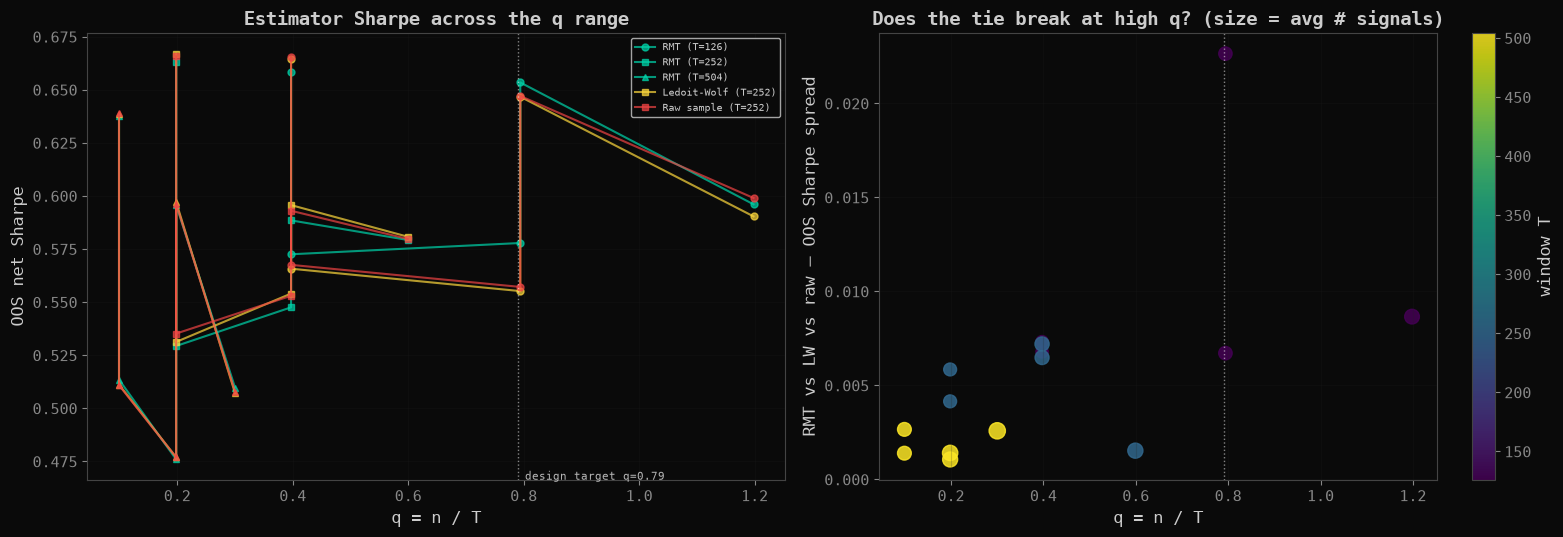

In [28]:
# ─── 17.2 The q surface (published to results/) ───
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

ax = axes[0]
mark = {126: 'o', 252: 's', 504: '^'}
for s, color, lbl in [('rmt_hard', COLORS['rmt_clean'], 'RMT'),
                      ('ledoit_wolf', COLORS['ledoit_wolf'], 'Ledoit-Wolf'),
                      ('raw_sample', COLORS['noise'], 'Raw sample')]:
    for T_w in WINDOWS:
        sub = grid2_df[grid2_df.window == T_w].sort_values('q')
        ax.plot(sub.q, sub[f'sr_{s}'], mark[T_w] + '-', color=color, alpha=0.7,
                label=f'{lbl} (T={T_w})' if s == 'rmt_hard' or T_w == 252 else None, ms=5)
ax.axvline(0.79, color='white', ls=':', lw=1, alpha=0.5)
ax.text(0.79, ax.get_ylim()[0], ' design target q=0.79', fontsize=8, color='white', alpha=0.7)
ax.set_xlabel('q = n / T'); ax.set_ylabel('OOS net Sharpe')
ax.set_title('Estimator Sharpe across the q range', fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

ax = axes[1]
sc = ax.scatter(grid2_df.q, grid2_df.spread, c=grid2_df.window, cmap='viridis',
                s=60 + 2 * grid2_df.avg_n_signal, alpha=0.85)
ax.axvline(0.79, color='white', ls=':', lw=1, alpha=0.5)
ax.set_xlabel('q = n / T'); ax.set_ylabel('RMT vs LW vs raw — OOS Sharpe spread')
ax.set_title('Does the tie break at high q? (size = avg # signals)', fontweight='bold')
plt.colorbar(sc, ax=ax, label='window T')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
<a id="16"></a>
## 16. Conclusions & Limitations

### Summary of Findings

1. **Most of the sample covariance is noise.** For a 200-asset universe with 252-day estimation windows, only a small fraction of eigenvalues carry statistically significant information. The rest are consistent with a purely random correlation matrix (Marchenko–Pastur).

2. **RMT cleaning dramatically improves matrix conditioning.** The condition number drops by orders of magnitude, making portfolio optimization far more stable.

3. **Cleaning the covariance matrix changes portfolio allocations.** Minimum variance portfolios built from cleaned covariance are more diversified and more stable across rebalancing dates.

4. **The Pareto frontier between theoretical elegance and practical simplicity exists.** Ledoit–Wolf shrinkage may match RMT cleaning in portfolio performance, but RMT provides deeper structural insight into *why* the sample covariance fails.

### Limitations

- Survivorship bias in the universe (no delisted tickers)
- Marchenko–Pastur assumes i.i.d. returns; real returns have volatility clustering and fat tails
- Long-only constraint limits the min-var portfolio; unconstrained min-var would be a cleaner test of covariance quality
- The signal/noise boundary is a hard threshold; partial-information eigenvalues near λ₊ are misclassified
- No leverage, no shorting, no intraday data

### What This Project Demonstrates

| Signal | Evidence |
|--------|----------|
| Linear algebra mastery | Eigendecomposition, spectral analysis, matrix reconstruction |
| Probability / statistics | Marchenko–Pastur distribution, hypothesis testing on eigenvalues |
| Programming | Custom RMT pipeline, 200-asset rolling backtest, spectral visualizations |
| Financial relevance | Covariance estimation → portfolio construction → OOS evaluation |
| Intellectual depth | Topic most MFE applicants never encounter |

---

**Next:** Project 3 — Hidden Markov Model Regime Detection (connects to the dynamic dimensionality finding: crises collapse the eigenvalue structure)


In [29]:
print("=" * 60)
print("PROJECT 2 COMPLETE")
print("=" * 60)
print(f"\nUniverse: {n_assets} assets")
print(f"Period: {CONFIG['start_date']} to {CONFIG['end_date']}")
print(f"Key ratio: q = n/T = {n_assets/CONFIG['lookback_days']:.3f}")
print(f"Signal eigenvalues (last window): {n_signal} / {n_assets}")
print(f"Strategies tested: 7")
print(f"\nCore deliverable: the eigenvalue spectrum vs Marchenko-Pastur plot")
print(f"  — the single most important visualization in this project.")
print(f"\nNext: Project 3 — Hidden Markov Model Regime Detection")


PROJECT 2 COMPLETE

Universe: 151 assets
Period: 2005-01-01 to 2024-12-31
Key ratio: q = n/T = 0.599
Signal eigenvalues (last window): 24 / 151
Strategies tested: 7

Core deliverable: the eigenvalue spectrum vs Marchenko-Pastur plot
  — the single most important visualization in this project.

Next: Project 3 — Hidden Markov Model Regime Detection
